# LCR VALIDATION

For context to this analysis and graph we refer you to https://docs.google.com/document/d/1otlVdPpbHqCvto2n8AFifXVa3CzpinqR1I7iASTCAKA/edit?tab=t.0 


In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import matplotlib.ticker as mtick

from datetime import datetime
import os

import sys

current_directory = os.getcwd()
risk_pylibrary_path = current_directory.replace('user_libs/fgv31/RMT_validations','')
repo_path = current_directory.replace('risk_pylibrary/user_libs/fgv31/RMT_validations','')

sys.path.append(repo_path)
sys.path.append(risk_pylibrary_path)


import tools.snowflake_db.db_connection as db

## HQLA

In [2]:
sql_query_hqla = """
    WITH group_accounts AS (
            SELECT DISTINCT account_id, group_account
            FROM teams_prd.risk_management_source.src__risk_management__lcr_template_mapping
            WHERE group_account IS NOT NULL
        )
        , lcr_mapping AS (
            SELECT lcr_template_mapping.account_id
                , lcr_template_mapping.be_id
                , lcr_template_mapping.sheet_name
                , lcr_template_mapping.row_name
                , lcr_template_mapping.customer
                , lcr_template_mapping.category_name
                , lcr_template_mapping.source_type
                , lcr_template_mapping.amount_type
                , lcr_template_mapping.group_account
                , lcr_template_mapping.id_type
                , lcr_template_mapping.end_date
                , lcr_template.item_name
                , lcr_template.standard_weight
            FROM teams_prd.risk_management_source.src__risk_management__lcr_template as lcr_template
            INNER JOIN teams_prd.risk_management_source.src__risk_management__lcr_template_mapping as lcr_template_mapping
                ON lcr_template.SHEET_NAME  = lcr_template_mapping.SHEET_NAME
                    AND lcr_template.ROW_NAME = lcr_template_mapping.ROW_NAME
        )
        , flipping_accounts AS (
            SELECT DISTINCT account_id
            FROM lcr_mapping
            GROUP BY account_id, customer
            HAVING COUNT(account_id) > 1
        )
        , data_union AS (

            SELECT report_dt
                , snapshot_dt
                , amount_eur
                , source_type
                , amount_type
                , account_id
                , NULL AS be_account_id
                , customer
            FROM teams_prd.risk_management_transform.trf_curr__risk_management__treasury_bonds_deposits_30d
            GROUP BY ALL

            UNION ALL

            SELECT report_dt
                , snapshot_dt
                , amount_eur
                , source_type
                , NULL AS amount_type
                , account_id
                , NULL AS be_account_id
                , NULL AS customer
            FROM teams_prd.risk_management_transform.trf__risk_management__overnight_deposits
        )

        
    SELECT d_a.report_dt
        , d_a.snapshot_dt
        , d_a.amount_eur
        , (d_a.amount_eur * lcr_mapping.standard_weight) AS amount_eur_weighted
        , d_a.source_type
        , d_a.amount_type
        , d_a.account_id
        , d_a.be_account_id
        , d_a.customer
        , lcr_mapping.sheet_name as sheet_name
        , lcr_mapping.row_name
        , lcr_mapping.category_name
        , lcr_mapping.item_name
        , lcr_mapping.standard_weight
        , concat(
            d_a.source_type,
            '-',
            to_char(d_a.report_dt, 'yyyymmdd'),
            '-',
            ifnull(d_a.account_id, ''),
            '-',
            ifnull(d_a.customer, ''),
            '-',
            ifnull(d_a.amount_type, '')
        ) as surrogate_ky
        , current_timestamp() as _metadata__updated_at
    FROM (
        /* Final aggregation to net out group accounts */
        SELECT report_dt
            , MAX(snapshot_dt) AS snapshot_dt
            , SUM(amount_eur) AS amount_eur
            , source_type
            , amount_type
            , account_id
            , be_account_id
            , customer
        FROM data_union
        GROUP BY ALL
    ) AS d_a
    INNER JOIN lcr_mapping
        ON NVL(lcr_mapping.account_id,'0') = NVL(d_a.account_id,'0')
            AND NVL(lcr_mapping.be_id,'0') = NVL(d_a.be_account_id,'0')
            AND (lcr_mapping.customer IS NULL
                OR NVL(lcr_mapping.customer,'0') = NVL(d_a.customer,'0'))
            AND NVL(lcr_mapping.amount_type,'0') = NVL(d_a.amount_type,'0')
    LEFT JOIN flipping_accounts AS f_a
        ON d_a.account_id = f_a.account_id
    WHERE amount_eur <> 0
        /* Remove duplicate entries for accounts that can have both IN and OUT type
        but retain entries for non-flipping and other assets.
        */
        AND (
            (f_a.account_id IS NULL)
            OR (lcr_mapping.id_type = 'Other')
            OR (d_a.amount_eur > 0 AND lcr_mapping.sheet_name = 'C 74.00.a')
            OR (d_a.amount_eur < 0 AND lcr_mapping.sheet_name = 'C 73.00.a')
        )
        /* Only use mapped accounts until they were removed from RegRep */
        AND (lcr_mapping.end_date IS NULL OR lcr_mapping.end_date >= d_a.report_dt)
        AND (lcr_mapping.sheet_name = 'C 72.00.a')
        -- AND (lcr_mapping.sheet_name = 'C 72.00.a' OR lcr_mapping.category_name = 'Treasury Deposits, Body')
        -- AND lcr_mapping.category_name = 'Treasury Deposits, Body'
    order by d_a.report_dt desc
"""
df = db.run_query(query=sql_query_hqla)


     ------------------------------------------------------------
               Risk @ Trade Republic Bank GmbH
     ------------------------------------------------------------
      Node: fgv	User: fgv
      Python version 3.12.7 (v3.12.7:0b05ead877f, Sep 30 2024, 23:18:00) [Clang 13.0.0 (clang-1300.0.29.30)]
      pandas: 2.2.3	numpy: 2.2.0
      Kernel started 2024-12-16 11:06
     ------------------------------------------------------------
Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://traderepublic.okta.com/app/snowflake/exk18zobx3kssJFvx417/sso/saml?SAMLRequest=nZJbc9owEIX%2Fikd9tiUbhosGyFAIhExIaTCZTt5keyEqtuRqZUz66ytz6aQPyUPfNNLZ%2FY727ODmWOTeAQxKrYYkDBjxQKU6k2o3JJt45veIh1aoTORawZC8AZKb0QBFkZd8XNlX9QS%2FKkDruUYKefMwJJVRXAuUyJUoALlN%2BXq8fOBRwLhABGMdjlxKMpSO9WptySmt6zqo

/Users/fgv/Documents/Coding/repos/risk_pylibrary/tools/snowflake_db/db_connection.py:179: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


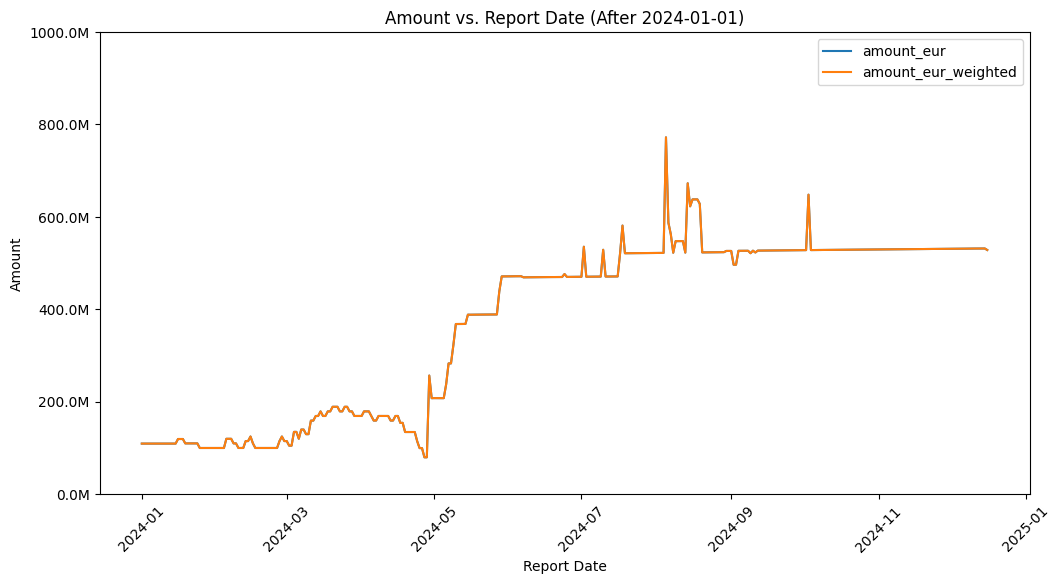

In [3]:
# Assuming your DataFrame is named 'df'
plt.figure(figsize=(12, 6))  # Adjust width and height as needed
# Filter data for report dates after 01/01/2024
df_filtered = df[(df['report_dt'] >= datetime(2024,1,1).date())]
# Group the data by date and sum the amounts
df_grouped = df_filtered.groupby('report_dt')[['amount_eur', 'amount_eur_weighted']].sum()
# Reset the index to make 'report_dt' a regular column
df_grouped.reset_index(inplace=True)

sns.lineplot(x='report_dt', y='amount_eur', data=df_grouped, label='amount_eur')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df_grouped, label='amount_eur_weighted')

plt.title('Amount vs. Report Date (After 2024-01-01)')
plt.xlabel('Report Date')
plt.ylabel('Amount')
plt.legend()
plt.xticks(rotation=45)

# Set y-axis limit to 10 million euros
plt.ylim(0, 1000000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

Here we see that there is no difference ever between the hqla weighted and not weighted amount 

In [4]:
sql_query_hqla_tresury_bond = """
            SELECT report_dt
                , snapshot_dt
                , amount_eur
                , source_type
                , amount_type
                , account_id
                , NULL AS be_account_id
                , customer
            FROM teams_prd.risk_management_transform.trf_curr__risk_management__treasury_bonds_deposits_30d
            GROUP BY ALL
"""
df2 = db.run_query(query=sql_query_hqla_tresury_bond)
df2.head(2)

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://traderepublic.okta.com/app/snowflake/exk18zobx3kssJFvx417/sso/saml?SAMLRequest=nZJbc9owEIX%2Fikd9tiUBhaABMlyGlE5IaSCdad6EvTgaZMnRyhjy6ytunfQheeibRjq739Ge7d3uCx3twKGypk94wkgEJrWZMnmfPK2m8Q2J0EuTSW0N9MkBkNwOeigLXYph5V%2FMI7xWgD4KjQyK40OfVM4IK1GhMLIAFD4Vy%2BH8XjQSJiQiOB9w5FKSoQqsF%2B9LQWld10ndTKzLaYMxRlmXBtVR8oW8Q5SfM0pnvU2tvpbsw58%2BQHDKWkdEUATC4lI4UuY8gs8o67MIxbfVahEvfixXJBpefze2BqsC3BLcTqXw9Hh%2FNoDBwd28fdPsdBKo4hSMd1LHPEFj642WW0htUVY%2BNE7CiW4go9rmKoxrNumTcquy7mv2zLp39VyODtjcHYad1kH%2F7GykzHf5w1RqV4%2FyGdT5%2BHdKol%2FXcBvHcGeIFczMMVIfrlijFfNGzNsrzgRrC%2F41YV3%2BTKJJiFQZ6U%2BVV9%2FBaQYOymqtVZrYrZcni7Is6V%2F3FPZbfvNm1%2FvmFvH7dLdv8Q5FtPSYGzmvjjjZcIP%2FGEiPvm9wWcSHkM1ssrDB1iGaWldI%2F3F0POGnG5XFm5NUQCGVHmaZA8QQoda2HjuQPuy7dxUQOjhT%2F934

/Users/fgv/Documents/Coding/repos/risk_pylibrary/tools/snowflake_db/db_connection.py:179: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,report_dt,snapshot_dt,amount_eur,source_type,amount_type,account_id,be_account_id,customer
0,2024-01-09,2024-01-09,9946300.0,Treasury_Bonds,Body,treasury_bonds,None,None
1,2024-01-22,2024-01-25,9964400.0,Treasury_Bonds,Body,treasury_bonds,None,None


In [5]:
df2[(df2['report_dt']== datetime(2024,3,15).date()) & (df2['account_id']=='treasury_bonds')].groupby('report_dt')['amount_eur'].sum()

report_dt
2024-03-15    1.792508e+08
Name: amount_eur, dtype: float64

In [6]:
sql_query_hqla_overnight_deposits = """
        SELECT report_dt
            , snapshot_dt
            , amount_eur
            , source_type
            , NULL AS amount_type
            , account_id
            , NULL AS be_account_id
            , NULL AS customer
        FROM teams_prd.risk_management_transform.trf__risk_management__overnight_deposits
"""
df3 = db.run_query(query=sql_query_hqla_overnight_deposits)
df3.head(2)

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://traderepublic.okta.com/app/snowflake/exk18zobx3kssJFvx417/sso/saml?SAMLRequest=nZJPc9owEMW%2Fikc927KBsYkGyFAYWtqQUDC005tsL0SDLRmtjCGfvjJ%2FMskhOfSmkd7u72nf9u6PRe4cQKNQsk8CzycOyFRlQm77ZBVP3C5x0HCZ8VxJ6JMTILkf9JAXecmGlXmWC9hXgMaxjSSy5qFPKi2Z4iiQSV4AMpOy5XD2wFqezzgiaGNx5FqSobCsZ2NKRmld117d9pTe0pbv%2B9S%2Fo1bVSL6QN4jyc0aplVGpym8lR%2FunDxAB9TsNwiosYX4t%2FCrkZQSfUZKLCNn3OJ6786dlTJzh7XcjJbEqQC9BH0QKq8XDxQBaB99mYbcdRR5UbgrSaJ67gYdS1Zuc7yBVRVkZ29izJ7qBjOZqK%2By4puM%2BKXci2%2F9cFHF52q94aFZ3f4bwOzyMxGk024%2FWL0XYDvfJr8fZNlknaUqc9S3cVhPuFLGCqWwiNfbKb3XcoOUGYRz4zA9ZEHlRFP4lzthGKiQ358qbb%2Bs0Aw1lleQi9dTO8LNFXpb01T2F4y7ovqjk2N4h%2Fpgcjp0gooiKNrmRy%2Bqwsw09%2BI%2BB9OjbBtdFfLTZTMdzZW2dnInSBTcfRxd4wflGZO7mLGVQcJEPs0wDoo0wz1U90sCN3XejKyB0cKG%2B3%2FjBPw

/Users/fgv/Documents/Coding/repos/risk_pylibrary/tools/snowflake_db/db_connection.py:179: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,report_dt,snapshot_dt,amount_eur,source_type,amount_type,account_id,be_account_id,customer
0,2022-09-30,2024-06-24,300000470.0,SAP_Balances,None,MDEEURTRBKDEBBXXX,None,None
1,2022-10-01,2024-06-24,300000470.0,SAP_Balances,None,MDEEURTRBKDEBBXXX,None,None


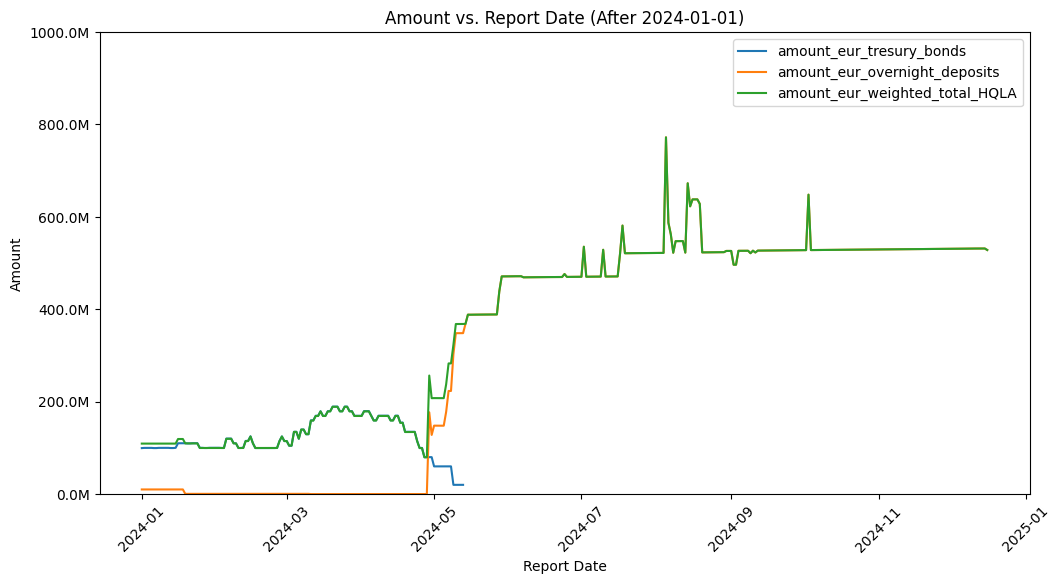

In [7]:
# Assuming your DataFrame is named 'df'
plt.figure(figsize=(12, 6))  # Adjust width and height as needed

# Filter data for report dates after 01/01/2024
df2_filtered = df2[(df2['report_dt'] >= datetime(2024,1,1).date())]
# Group the data by date and sum the amounts
df2_grouped = df2_filtered[(df2_filtered['account_id']=='treasury_bonds')].groupby('report_dt')[['amount_eur']].sum()
# Reset the index to make 'report_dt' a regular column
df2_grouped.reset_index(inplace=True)

sns.lineplot(x='report_dt', y='amount_eur', data=df2_grouped, label='amount_eur_tresury_bonds')

# Filter data for report dates after 01/01/2024
df3_filtered = df3[(df3['report_dt'] >= datetime(2024,1,1).date())]
# Group the data by date and sum the amounts
df3_grouped = df3_filtered.groupby('report_dt')[['amount_eur']].sum()
# Reset the index to make 'report_dt' a regular column
df3_grouped.reset_index(inplace=True)

sns.lineplot(x='report_dt', y='amount_eur', data=df3_grouped, label='amount_eur_overnight_deposits')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df_grouped, label='amount_eur_weighted_total_HQLA')

plt.title('Amount vs. Report Date (After 2024-01-01)')
plt.xlabel('Report Date')
plt.ylabel('Amount')
plt.legend()
plt.xticks(rotation=45)

# Set y-axis limit to 10 million euros
plt.ylim(0, 1000000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

#### Tresury bond drill down 

In [8]:
sql_query_hqla_tresury_bond_source = """
SELECT * 
FROM 
teams_prd.finance_staging.snapshot_stg__finance__treasury_bond_position
"""
df4 = db.run_query(query=sql_query_hqla_tresury_bond_source)
df4.head(2)

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://traderepublic.okta.com/app/snowflake/exk18zobx3kssJFvx417/sso/saml?SAMLRequest=nZJNc9owEIb%2Fikc927IMw4cGyBAILZ2QegLJoTdhL6CxLblaGTv8%2Bsp8dNJDcshNI727z6t9d3TXFLl3BINSqzFhQUg8UIlOpdqPyctm4Q%2BIh1aoVORawZi8AZK7yQhFkZd8WtmDeoY%2FFaD1XCOFvH0Yk8oorgVK5EoUgNwmfD1dPfIoCLlABGMdjlxLUpSOdbC25JTWdR3UnUCbPY3CMKThkDpVK%2FlG3iHKzxml0VYnOr%2BVNO5PHyAYDbstwikcIb4W3kt1GcFnlO1FhPzHZhP78a%2F1hnjT2%2B9mWmFVgFmDOcoEXp4fLwbQOfi%2B6g06%2FX4AlZ%2BAskbkPgtQ6XqXiwwSXZSVdY0Dd6I7SGmu99KNazkfkzKTaRY%2FFPdCV0%2Br7qB3gOw020%2FjkxKNqZnYmrpr1kV6XC%2F2h4eEeK%2B3cKM23CViBUvVRmrdVRh1fRb5rLdhIQ97PGJBZzj8Tby5i1QqYc%2BVN9%2FOaQoGymqbyyTQmRVni6Is6T%2F3FJqMDU5623QyxJ%2BLY9NlfYqoaZsbuawOP9swky8MZETfN7gu4pPLZjmPtbP15i20KYT9ODoWsPONTP3dWcqhEDKfpqkBRBdhnut6ZkBYt%2B%2FWVEDo5EL9

/Users/fgv/Documents/Coding/repos/risk_pylibrary/tools/snowflake_db/db_connection.py:179: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,report_date,name,isin,trade_id,dbt_surrogate_key,coupon,coupon_type,coupon_frequency,coupon_base,benchmark_for_floating,...,country_of_risk_parent,country_of_domicile_parent,obligor_industry_subgroup,is_development_bank,is_member_state,is_central_government,next_report_date,trade_status,extraction_date,extraction_ts
0,2024-03-01,FRENCH DISCOUNT T-BILL,FR0127921304,529900920231129007,5cf918f38a1a429fbac8998a25c5a1fd,0.0,ZERO COUPON,0.0,ACT/360,None,...,FR,FR,Sovereign,N,Y,N,None,Y,2024-03-04,2024-03-04 11:00:37
1,2024-03-01,FINNISH T-BILL,FI4000561279,529900920231129006,da7cd508e1f335f34ccefc6a32923324,0.0,ZERO COUPON,0.0,ACT/360 NON-EOM,None,...,FI,FI,Sovereign,N,Y,N,None,Y,2024-03-04,2024-03-04 11:00:37


In [9]:
df4['name'].unique()

array(['FRENCH DISCOUNT T-BILL', 'FINNISH T-BILL',
       'LAND NORDRHEIN-WESTFALEN', 'GERMAN TREASURY BILL',
       'DUTCH TREASURY CERT', 'EUROPEAN UNION BILL', 'EFSF',
       'AUSTRIAN T-BILL', 'LAND HESSEN', 'ESM TBILL', 'KOMMUNEKREDIT',
       'TREASURY CERTIFICATES'], dtype=object)

#### Overnight deposits drilldown

In [10]:
sql_query_overnight_deposits = """ --sql
WITH 
ssdt as (

     -- check if there are missing data comparing to the fill dataset
        select
            date as report_dt
        from
            teams_prd.risk_management_transform.trf__risk_management__ref_dates
        where
            date <= current_date()
    ),
    
    backend as (

    -- WHAT IS THIS ? 
        SELECT
            "account_id" as account_id,
            TO_DATE("booking_date") as booking_date,
            TO_DATE("extraction_timestamp") as snapshot_dt,
            "amount" as amount,
            'backend' as source_type
        FROM
            BACKEND_PRD.SEPA_PROCESSOR.ANONYMIZED_T2_BANK_BOOKING
        WHERE
            1 = 1
            AND "transaction_type" = 'DBIT'
            AND "booking_type" = 'LIQT'
            AND "booking_date" >= '2023-12-31'
            AND "recipient_bic" = 'DDEEURTRBKDEBBXXX' --
        qualify row_number() over (partition by "booking_date" order by
                                                    "booking_date" desc) = 1
    ),
    sap as (
        -- add data from SAP source for account 10102100 LOOKS LIKE THIS IS UPDATED EVERY 15 DAYS 
        select
            report_dt
            , snapshot_dt
            , sum(amount_eur) as amount_eur
            , account_id
            , source_type
        from teams_prd.risk_management_transform.trf_snapshot__risk_management__display_line_items_in_general_ledger
        where account_id = '10102100'
        group by all
    ),
    tsy_overnight_deposits as (
    
        select *
            , 'treasury_upload' as source_type
        from teams_prd.regulatory_reporting_source.src_snapshot__regulatory_reporting__treasury_overnight_deposits
        qualify row_number() over (partition by start_date, end_date order by snapshot_dt desc) = 1
    ),
    data as (
        select
            ssdt.report_dt
            , coalesce(b.snapshot_dt, tod.snapshot_dt, sap.snapshot_dt) as snapshot_dt
            , 'MDEEURTRBKDEBBXXX' as account_id
            , b.amount as b_amount
            , b.booking_date as b_date
            , tod.amount_eur as tod_amount 
            , tod.start_date as tod_start_date
            , tod.end_date as tod_end_date
            , sap.amount_eur as sap_amount
            
            -- Checks the first non-null vaue in the order and reports that
            , sum(coalesce(b.amount, tod.amount_eur, sap.amount_eur)) as amount_eur
            , coalesce(b.source_type, tod.source_type, sap.source_type) as source_type
        from ssdt
        left join backend as b
            on ssdt.report_dt = b.booking_date
        left join tsy_overnight_deposits as tod
            on ssdt.report_dt >= tod.start_date
            and ssdt.report_dt < tod.end_date
        left join sap
            on ssdt.report_dt = sap.report_dt
        group by all
    )

select
    report_dt
    , snapshot_dt
    , account_id
    , b_amount
    , b_date
    , tod_amount 
    , tod_start_date
    , tod_end_date
    , sap_amount
    , ifnull(
        amount_eur, lag(amount_eur) IGNORE NULLS over (order by report_dt asc)) as amount_eur
    , ifnull(
        source_type, lag(source_type) IGNORE NULLS over (order by report_dt asc)) as source_type
    , 'Central Bank Account' as account_name
from data
where amount_eur is not null 
    and amount_eur <>0 

order by report_dt desc;

"""
df5 = db.run_query(query=sql_query_overnight_deposits)
df5.head(2)

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://traderepublic.okta.com/app/snowflake/exk18zobx3kssJFvx417/sso/saml?SAMLRequest=nZJfb9owFMW%2FSuQ9J45DBMwCKtaIFlS2CNJV2puTOOCR2KmvQ0I%2F%2FRz%2BTN1D%2B7A3yz73%2Fo7vuZO7riqdI9cglJwi4vnI4TJTuZC7KXpOFu4YOWCYzFmpJJ%2BiEwd0N5sAq8qazhuzlxv%2B2nAwjm0kgfYPU9RoSRUDAVSyigM1Gd3O10808HzKALg2FoeuJTkIy9obU1OM27b12oGn9A4Hvu9j%2Fyu2ql7yBb1D1J8zaq2MylR5K%2Bnsnz5AEOyHPcIqLCG%2BFn4T8jKCzyjpRQT0MUliN%2F6xTZAzv%2F3uXkloKq63XB9Fxp83TxcDYB08rIfjwWjk8cbNuDSalS7xQKq2KNmBZ6qqG2Mbe%2FaEC57jUu2EHdcymqL6IPLF71VU7B7ZJkrXaZS9FKdF06XJNj5t9l32tkmX4cOKFC%2BD13WGnJ%2B3cIM%2B3CVAw5eyj9TYKz8IXRK4ZJgQn%2FpDGoQeCcNfyIlspEIyc668%2BbZOc6553aSlyDx1MOxskdU1%2Fuse8%2B5Axm8q7QYHgNXi2IVkhAEU7nNDl9WhZxt69h8DmeD3Da6L%2BN1ms4xiZW2dnIXSFTMfR0c8cr4RuVucpZRXTJTzPNccwEZYlqq915wZu%2B9GNx

/Users/fgv/Documents/Coding/repos/risk_pylibrary/tools/snowflake_db/db_connection.py:179: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,report_dt,snapshot_dt,account_id,b_amount,b_date,tod_amount,tod_start_date,tod_end_date,sap_amount,amount_eur,source_type,account_name
0,2024-12-16,2024-12-02,MDEEURTRBKDEBBXXX,NaN,None,NaN,None,None,5.282796e+08,5.282796e+08,SAP_Balances,Central Bank Account
1,2024-12-15,2024-12-16,MDEEURTRBKDEBBXXX,NaN,None,531546950.0,2024-12-13,2024-12-16,5.282796e+08,5.315470e+08,treasury_upload,Central Bank Account


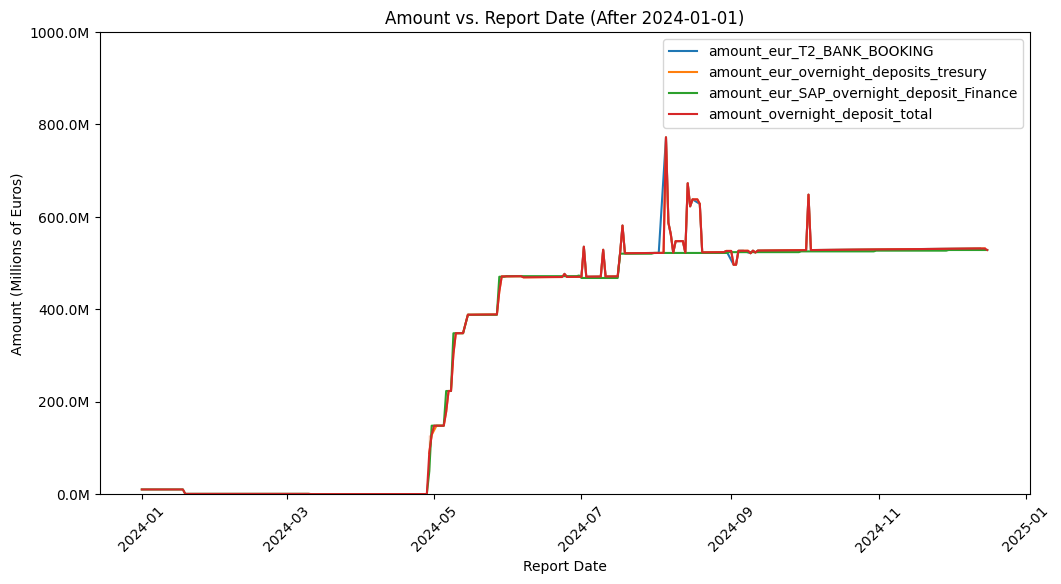

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your DataFrame is named 'df'
plt.figure(figsize=(12, 6))  # Adjust width and height as needed


# Filter data for report dates after 01/01/2024
df5_filtered = df5[(df5['report_dt'] >= datetime(2024,1,1).date())]


sns.lineplot(x='report_dt', y='b_amount', data=df5_filtered, label='amount_eur_T2_BANK_BOOKING')
sns.lineplot(x='report_dt', y='tod_amount', data=df5_filtered, label='amount_eur_overnight_deposits_tresury')
sns.lineplot(x='report_dt', y='sap_amount', data=df5_filtered, label='amount_eur_SAP_overnight_deposit_Finance')
sns.lineplot(x='report_dt', y='amount_eur', data=df5_filtered, label='amount_overnight_deposit_total')


plt.title('Amount vs. Report Date (After 2024-01-01)')
plt.xlabel('Report Date')
plt.ylabel('Amount (Millions of Euros)')
plt.legend()
plt.xticks(rotation=45)

# Set y-axis limit to 10 million euros
plt.ylim(0, 1000000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()


In [12]:
df5.head(10)

,report_dt,snapshot_dt,account_id,b_amount,b_date,tod_amount,tod_start_date,tod_end_date,sap_amount,amount_eur,source_type,account_name
0,2024-12-16,2024-12-02,MDEEURTRBKDEBBXXX,NaN,None,NaN,None,None,5.282796e+08,5.282796e+08,SAP_Balances,Central Bank Account
1,2024-12-15,2024-12-16,MDEEURTRBKDEBBXXX,NaN,None,531546950.0,2024-12-13,2024-12-16,5.282796e+08,5.315470e+08,treasury_upload,Central Bank Account
2,2024-12-14,2024-12-16,MDEEURTRBKDEBBXXX,NaN,None,531546950.0,2024-12-13,2024-12-16,5.282796e+08,5.315470e+08,treasury_upload,Central Bank Account
3,2024-12-13,2024-12-16,MDEEURTRBKDEBBXXX,5.315469e+08,2024-12-13,531546950.0,2024-12-13,2024-12-16,5.282796e+08,5.315469e+08,backend,Central Bank Account
4,2024-12-12,2024-12-16,MDEEURTRBKDEBBXXX,5.314990e+08,2024-12-12,531498967.0,2024-12-12,2024-12-13,5.282796e+08,5.314990e+08,backend,Central Bank Account
5,2024-12-11,2024-12-16,MDEEURTRBKDEBBXXX,5.314510e+08,2024-12-11,531450989.0,2024-12-11,2024-12-12,5.282796e+08,5.314510e+08,backend,Central Bank Account
6,2024-12-10,2024-12-16,MDEEURTRBKDEBBXXX,5.314030e+08,2024-12-10,531403015.0,2024-12-10,2024-12-11,5.282796e+08,5.314030e+08,backend,Central Bank Account
7,2024-12-09,2024-12-16,MDEEURTRBKDEBBXXX,5.313550e+08,2024-12-09,531355045.0,2024-12-09,2024-12-10,5.282796e+08,5.313550e+08,backend,Central Bank Account
8,2024-12-08,2024-12-16,MDEEURTRBKDEBBXXX,NaN,None,531211176.0,2024-12-06,2024-12-09,5.282796e+08,5.312112e+08,treasury_upload,Central Bank Account
9,2024-12-07,2024-12-16,MDEEURTRBKDEBBXXX,NaN,None,531211176.0,2024-12-06,2024-12-09,5.282796e+08,5.312112e+08,treasury_upload,Central Bank Account


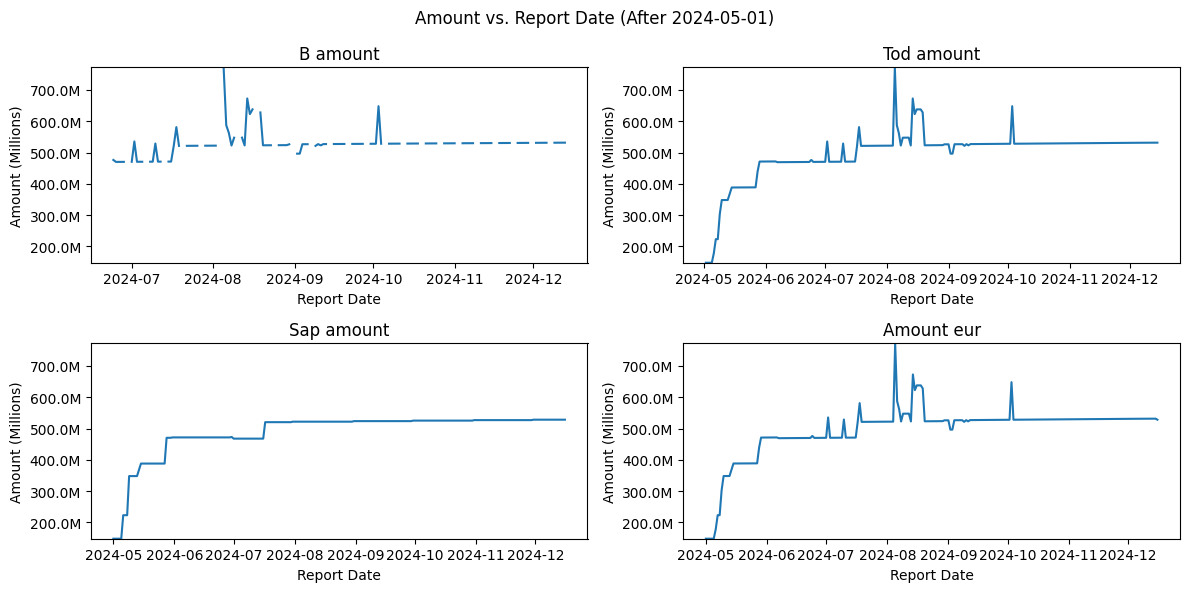

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# Filter data for report dates after 01/01/2024
df5_filtered = df5[(df5['report_dt'] >= datetime(2024, 5, 1).date())]

# 1. Define the subplot grid
rows, cols = 2, 2
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

# 2. Get a list of column names for the graphs (excluding the date column)
data_columns = ['b_amount', 'tod_amount', 'sap_amount', 'amount_eur']

# 3. Determine the global minimum and maximum y-values across all columns
y_min = df5_filtered[data_columns].min().min()
y_max = df5_filtered[data_columns].max().max()

# 4. Iterate through subplots and create line plots
for i in range(rows):
    for j in range(cols):
        # Get the current column name
        col_name = data_columns[i * cols + j]

        # Create the line plot on the current axis
        axes[i, j].plot(df5_filtered['report_dt'], df5_filtered[col_name], label=col_name)

        # Set common labels and title (optional)
        axes[i, j].set_xlabel('Report Date')
        axes[i, j].set_ylabel('Amount (Millions)')
        axes[i, j].set_title(col_name.replace('_', ' ').capitalize())

        # Set the same y-axis limits for all subplots
        axes[i, j].set_ylim(y_min, y_max)

        # Format y-axis ticks as millions
        axes[i, j].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

# 5. Adjust layout and add legend (optional)
fig.suptitle('Amount vs. Report Date (After 2024-05-01)', fontsize=12)
plt.tight_layout()
# plt.legend(loc='upper center', bbox_to_anchor=(1.2, 1))

plt.show()

In [14]:
sql_query_T2_balances = """ --sql
WITH balances_account as (
    SELECT 
    *,
     "account_id" as account_id
        , "account_bic" as account_bic
        , "amount" as amount
        , "currency" as currency
        , DATE_TRUNC('day', "indicated_at") as indicated_attt
    FROM
            BACKEND_PRD.SEPA_PROCESSOR.ANONYMIZED_T2_BALANCE

    where 
        "amount" > 0
        AND (account_id = 'MDEEURTRBKDEBBXXX' OR account_id = 'RDEEURTRBKDEBBXXX' OR account_id  ='UDEEURTRBKDEBBXXXDE1')
        -- AND "indicated_at"<=  '2024-10-01'
        qualify row_number() over (partition by account_id,indicated_attt order by
                                             "indicated_at" desc) = 1
        -- AND account_id = 'RDEEURTRBKDEBBXXX'
    order by "indicated_at" desc
    )

select 
sum("amount"), indicated_attt
from balances_account
group by indicated_attt


"""
df6 = db.run_query(query=sql_query_T2_balances)
df6.head(2)

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://traderepublic.okta.com/app/snowflake/exk18zobx3kssJFvx417/sso/saml?SAMLRequest=nZJbc9owEIX%2Fikd9tmUD5aIBMhRKSmooA6TJ9E3YC1GRJUcrY%2BDXV%2BbSSR%2BSh75ppLP7He3Z7t0hk94eDAqteiQKQuKBSnQq1LZHHldjv008tFylXGoFPXIEJHf9LvJM5mxQ2Be1gNcC0HqukUJWPfRIYRTTHAUyxTNAZhO2HExjVgtCxhHBWIcj15IUhWO9WJszSsuyDMp6oM2W1sIwpGGHOlUl%2BUTeIPKPGbnRVida3koO7k%2FvICIaNiqEUzjC%2FFr4RajLCD6irC8iZN9Wq7k%2F%2F7FcEW9w%2B91QKywyMEswe5HA4yK%2BGEDn4H7abNdbrQAKPwFlDZd%2BFKDS5UbyHSQ6ywvrGgfuRDeQUqm3wo1rMuqRfCdSkfxuZc3BKY%2B%2Fx%2BNZfRbfTy3vfH5%2BfXp%2BWHe2x6fWV9mMFkN7miTE%2B3kLt1aFO0EsYKKqSK27CmsNP6r5UXMVhSxssnoYNKLWL%2BKNXKRCcXuuvPl2TlMwkBdrKZJA7yw%2FW%2BR5Tv%2B6p3DYRe2TXh%2FqO8SH8f7gGlJETavcyGV12NmG6f%2FHQLr0bYPrIs5cNpPRXDtbR2%2BsTcbt%2B9FFQXS%2BEam%2FOUsZZFzIQZoaQHQRSqnL

/Users/fgv/Documents/Coding/repos/risk_pylibrary/tools/snowflake_db/db_connection.py:179: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,"sum(""amount"")",indicated_attt
0,5.462058e+08,2024-12-13
1,5.395455e+08,2024-12-12


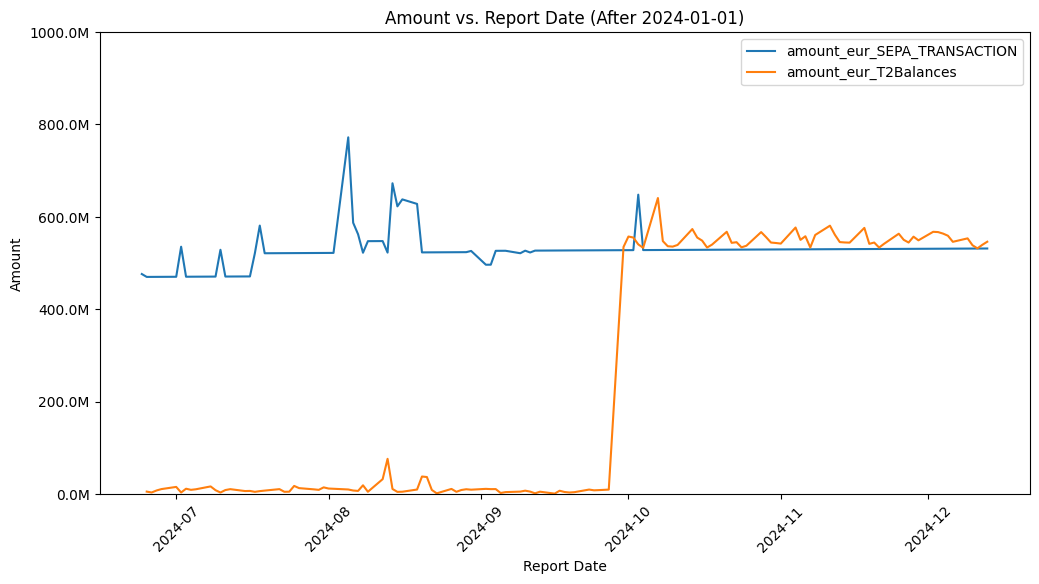

In [15]:
# Assuming your DataFrame is named 'df'
plt.figure(figsize=(12, 6))  # Adjust width and height as needed


# Filter data for report dates after 01/01/2024
df5_filtered = df5[(df5['report_dt'] >= datetime(2024,5,1).date())]
df6_filtered = df6[df6['indicated_attt'].dt.date >= datetime(2024, 5, 1).date()]


sns.lineplot(x='report_dt', y='b_amount', data=df5_filtered, label='amount_eur_SEPA_TRANSACTION',)
sns.lineplot(x='indicated_attt', y='sum("amount")', data=df6_filtered, label='amount_eur_T2Balances')

plt.title('Amount vs. Report Date (After 2024-01-01)')
# plt.yscale('log')
plt.xlabel('Report Date')
plt.ylabel('Amount')
plt.legend()
plt.xticks(rotation=45)

# Set y-axis limit to 10 million euros
plt.ylim(0, 1000000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

/var/folders/w6/wsq46twn0cx100v61grphj3m0000gn/T/ipykernel_36879/2621501230.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5_filtered['delta_amount'] = df5_filtered['b_amount'].diff()


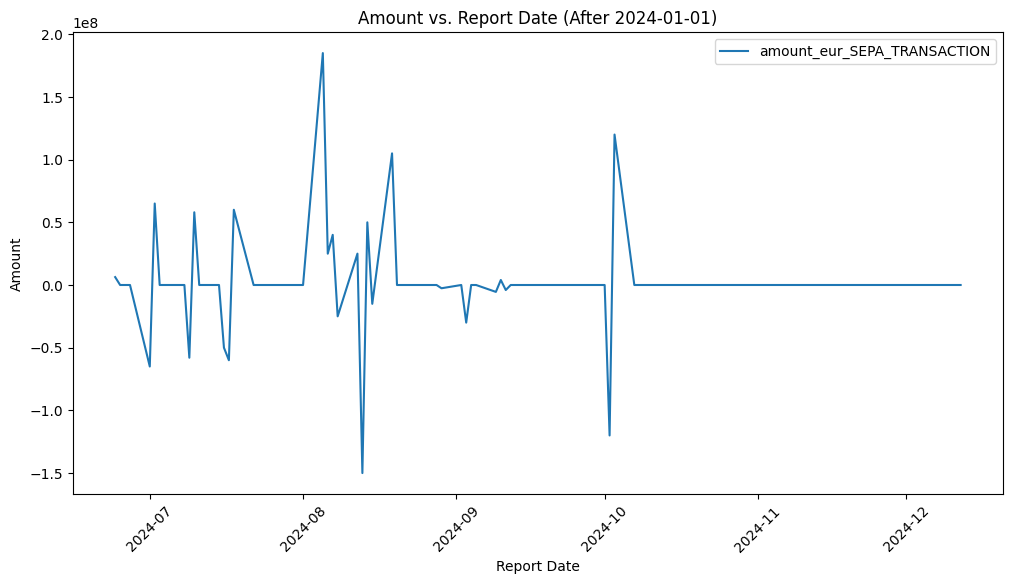

In [16]:
# Assuming your DataFrame is named 'df'
plt.figure(figsize=(12, 6))  # Adjust width and height as needed


# Filter data for report dates after 01/01/2024
df5_filtered = df5[(df5['report_dt'] >= datetime(2024,5,1).date())]


# df6_filtered = df6[df6['indicated_attt'].dt.date >= datetime(2024, 5, 1).date()]

df5_filtered['delta_amount'] = df5_filtered['b_amount'].diff()


sns.lineplot(x='report_dt', y='delta_amount', data=df5_filtered, label='amount_eur_SEPA_TRANSACTION',)
# sns.lineplot(x='indicated_attt', y='sum("amount")', data=df6_filtered, label='amount_eur_T2Balances')

plt.title('Amount vs. Report Date (After 2024-01-01)')
# plt.yscale('log')
plt.xlabel('Report Date')
plt.ylabel('Amount')
plt.legend()
plt.xticks(rotation=45)
plt.show()

## Net cashflows 30 days 

##### 

##### LCR breakdown

In [17]:
sql_lcrbreakdown = """
select * from teams_prd.risk_management_mart.mrt__risk_management__lcr_breakdown
"""
df7a = db.run_query(query=sql_lcrbreakdown)
df7a.head(2)

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://traderepublic.okta.com/app/snowflake/exk18zobx3kssJFvx417/sso/saml?SAMLRequest=nZJbc9owEIX%2Fikd9tuULwUQDZGgolJS0DJhkmjdhL0SDLTlaGUN%2BfWUumeQheeibRjq739Ge7d7si9zZgUahZI8Enk8ckKnKhNz0yDIZuR3ioOEy47mS0CMHQHLT7yIv8pINKvMs5%2FBSARrHNpLImoceqbRkiqNAJnkByEzKFoP7KQs9n3FE0MbiyLkkQ2FZz8aUjNK6rr068pTe0ND3fepfU6tqJN%2FIO0T5NaPUyqhU5ZeSvf3TJ4iA%2Bq0GYRWWMDsXfhfyNIKvKKuTCNnPJJm5sz%2BLhDiDy%2B9ulcSqAL0AvRMpLOfTkwG0Dsb37U4Uxx5UbgrSaJ67gYdS1eucbyFVRVkZ29izJ7qGjOZqI%2By4JsMeKbciu1qOq846%2BjH9OwlxMVcvu6unOPn1mCyvg9XjHTwc6oSPY%2F4atlLiPFzCDZtwJ4gVTGQTqbFXfthyg9AN2kngM7%2FNosgLY%2F%2BJOEMbqZDcHCsvvq3TDDSU1SoXqae2hh8t8rKkb%2B4p7LdB51Wt9tEW8W6027eCmCIq2uRGTqvDjjZ0%2Fz8G0qXvG5wX8bfNZjKcKWvr4IyULrj5PLrAC443InPXRymDgot8kGUaEG2Eea7qWw3c2H03ugJC%2Byfqx43v%2Fw

/Users/fgv/Documents/Coding/repos/risk_pylibrary/tools/snowflake_db/db_connection.py:179: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,report_dt,snapshot_dt,amount_eur,amount_eur_weighted,source_type,amount_type,account_id,be_account_id,customer,sheet_name,row_name,category_name,item_name,standard_weight,surrogate_ky,_metadata__updated_at,_projection_flag
0,2024-08-07,2024-08-08 00:00:00+00:00,-2545.15,-2545.15,SAP_Balances,None,20501001,None,1001337,C 73.00.a,0910,Accounts payable,others,1.0,SAP_Balances-20240807-20501001-1001337-,2024-12-16 09:00:42.882000+00:00,actuals
1,2022-10-04,2024-06-24 00:00:00+00:00,-11900.00,-11900.00,SAP_Balances,None,20501001,None,1000249,C 73.00.a,0910,Accounts payable,others,1.0,SAP_Balances-20221004-20501001-1000249-,2024-12-16 09:00:42.882000+00:00,actuals


In [18]:
df7a_filtered = df7a[(df7a['report_dt'] >= datetime(2024,1,1).date())]

df7a_inflows_weighted = df7a_filtered[df7a_filtered['sheet_name'] == 'C 74.00.a'].groupby('report_dt')[['amount_eur_weighted']].sum().reset_index()
df7a_outflows_weighted = df7a_filtered[df7a_filtered['sheet_name'] == 'C 73.00.a'].groupby('report_dt').agg({'amount_eur_weighted': lambda x: x.abs().sum()}).reset_index()# Merge DataFrames on 'report_dt'

# Merge DataFrames on 'report_dt'
merged_df7a_weighted = pd.merge(df7a_inflows_weighted, df7a_outflows_weighted, on='report_dt',how='outer')
df7a_outflows_weighted['amount_eur_weighted'] =  -df7a_outflows_weighted['amount_eur_weighted']
merged_df7a_weighted['net_cash_outflow_weighted'] = merged_df7a_weighted['amount_eur_weighted_x'] - merged_df7a_weighted['amount_eur_weighted_y']

In [19]:
merged_df7a_weighted[merged_df7a_weighted['report_dt']== datetime(2024,9,24).date()] #LCR Breakdown 

,report_dt,amount_eur_weighted_x,amount_eur_weighted_y,net_cash_outflow_weighted
267,2024-09-24,1.757334e+09,2.421875e+08,1.515146e+09


##### cashflow projection

In [20]:
sql_projections = """
select * from teams_prd.risk_management_mart.mrt__risk_management__lcr_cashflow_projections
"""
df7b = db.run_query(query=sql_projections)

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://traderepublic.okta.com/app/snowflake/exk18zobx3kssJFvx417/sso/saml?SAMLRequest=nZJPc9owEMW%2Fikc927KBAaIBMjQMrVucMhhyyE3YC6jIkqOVsZNPX5k%2FnfSQHHrTSG%2F397RvR%2FdNIb0TGBRajUkUhMQDlelcqP2YbNZzf0g8tFzlXGoFY%2FIKSO4nI%2BSFLNm0sge1gpcK0HqukULWPoxJZRTTHAUyxQtAZjOWTpMF6wQh44hgrMORa0mOwrEO1paM0rqug7obaLOnnTAMaXhHnaqVfCHvEOXnjNJoqzMtbyWN%2B9MHiIiGvRbhFI6wvBZ%2BFeoygs8o24sI2ff1eukvf6Vr4k1vv3vQCqsCTArmJDLYrBYXA%2BgcfEv6w%2B5gEEDlZ6Cs4dKPAlS63kl%2BhEwXZWVd48Cd6A5yKvVeuHHFszEpjyLXK2xwt6%2FnL1lSJ08%2F4%2B1UQfT4lh3C9BnSZFakSbwY7tTvTUa8p1u4nTbcGLGCWLWRWncVdnp%2B1PGj%2FjoKWdhn3WFw1%2B8%2BE2%2FmIhWK23PlzbdzmoOBstpKkQX6aPnZIi9L%2Btc9heYYDd%2F0tukeEX%2FMT00vGlBETdvcyGV12NmGmfzHQEb0fYPrIj66bOLZUjtbr95cm4Lbj6OLguh8I3J%2Fd5YyKLiQ0zw3gOgilFLXDwa4dftuTQWETi

/Users/fgv/Documents/Coding/repos/risk_pylibrary/tools/snowflake_db/db_connection.py:179: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [21]:
df7b_filtered = df7b[(df7b['report_dt'] >= datetime(2024,1,1).date())]
df7b_inflows_weighted = df7b_filtered[df7b_filtered['sheet_name'] == 'C 74.00.a'].groupby('report_dt')[['amount_eur_weighted']].sum().reset_index()
# df7_inflows_weighted['amount_eur_weighted'] =  0.75*df7_inflows_weighted['amount_eur_weighted']
df7b_outflows_weighted = df7b_filtered[df7b_filtered['sheet_name'] == 'C 73.00.a'].groupby('report_dt').agg({'amount_eur_weighted': lambda x: x.abs().sum()}).reset_index()# Merge DataFrames on 'report_dt'

# Merge DataFrames on 'report_dt'
merged_df7b_weighted = pd.merge(df7b_inflows_weighted, df7b_outflows_weighted, on='report_dt',how='outer')
df7b_outflows_weighted['amount_eur_weighted'] =  -df7b_outflows_weighted['amount_eur_weighted']
merged_df7b_weighted['net_cash_outflow_weighted'] = merged_df7b_weighted['amount_eur_weighted_x'] + merged_df7b_weighted['amount_eur_weighted_y']

In [22]:
merged_df7b_weighted[merged_df7b_weighted['report_dt']== datetime(2024,9,24).date()]


,report_dt,amount_eur_weighted_x,amount_eur_weighted_y,net_cash_outflow_weighted
267,2024-09-24,1.380232e+08,814032.68,1.388373e+08


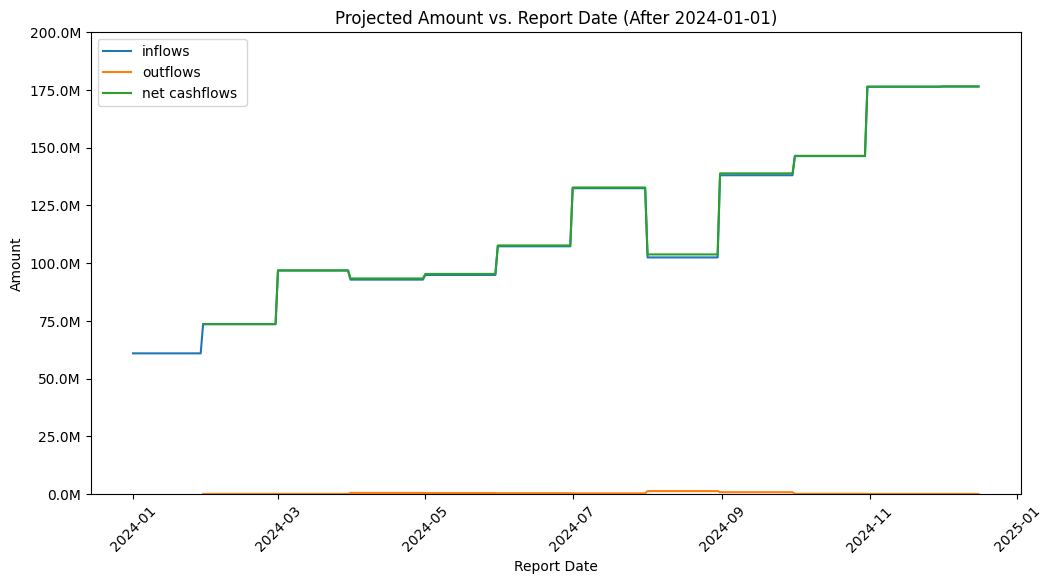

In [23]:
# Assuming your DataFrame is named 'df'
plt.figure(figsize=(12, 6))  # Adjust width and height as needed

sns.lineplot(x='report_dt', y='amount_eur_weighted_x', data=merged_df7b_weighted, label='inflows')
sns.lineplot(x='report_dt', y='amount_eur_weighted_y', data=merged_df7b_weighted, label='outflows')
sns.lineplot(x='report_dt', y='net_cash_outflow_weighted', data=merged_df7b_weighted, label='net cashflows ')

plt.title('Projected Amount vs. Report Date (After 2024-01-01)')
plt.xlabel('Report Date')
plt.ylabel('Amount')
plt.legend()
plt.xticks(rotation=45)

# Set y-axis limit to 10 million euros
plt.ylim(0, 200000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

##### cashflows 

In [24]:
sql_cashflows = """
select * from teams_prd.risk_management_mart.mrt__risk_management__lcr_cashflows
"""
df7c = db.run_query(query=sql_cashflows)

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://traderepublic.okta.com/app/snowflake/exk18zobx3kssJFvx417/sso/saml?SAMLRequest=nZJbc9owEIX%2Fikd9tmUbCkQDZAgMLU1ImEB6yZtsL6CxLLlaGQO%2FvjKXTvqQPPRNI53d72jP9m%2F3hfR2YFBoNSBREBIPVKozoTYD8rKa%2Bj3ioeUq41IrGJADILkd9pEXsmSjym7VM%2FyuAK3nGilkzcOAVEYxzVEgU7wAZDZly9H8gcVByDgiGOtw5FKSoXCsrbUlo7Su66BuBdpsaByGIQ1vqFM1kk%2FkDaL8mFEabXWq5bVk7%2F70DiKiYbtBOIUjLC6Fd0KdR%2FARJTmLkH1drRb%2B4mm5It7o%2BruxVlgVYJZgdiKFl%2BeHswF0Dr7MO71WtxtA5aegrOHSjwJUul5LnkOqi7KyrnHgTnQNGZV6I9y4ZpMBKXOR3e3u73mcHLPDr%2FpJvx6282P0o%2Bx1eKK6jyWqn%2FOj%2BIzb7TjJU%2BJ9v4YbN%2BHOECuYqSZS667CuO1HsR91VlHIwg5rt4I4jl%2BJN3GRCsXtqfLq2znNwEBZJVKkgc4tP1nkZUn%2Fuqewz6PeUSf7Vo74bbrbt6MuRdS0yY2cV4edbJjhfwykT982uCzio8tmNlloZ%2BvgTbUpuH0%2FuiiITjci89cnKYOCCznKMgOILkIpdT02wK3bd2sqIHR4pv

/Users/fgv/Documents/Coding/repos/risk_pylibrary/tools/snowflake_db/db_connection.py:179: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [25]:
df7c_filtered = df7c[(df7c['report_dt'] >= datetime(2024,1,1).date())]
df7c_inflows_weighted = df7c_filtered[df7c_filtered['sheet_name'] == 'C 74.00.a'].groupby('report_dt')[['amount_eur_weighted']].sum().reset_index()
# df7_inflows_weighted['amount_eur_weighted'] =  0.75*df7_inflows_weighted['amount_eur_weighted']
df7c_outflows_weighted = df7c_filtered[df7c_filtered['sheet_name'] == 'C 73.00.a'].groupby('report_dt').agg({'amount_eur_weighted': lambda x: x.abs().sum()}).reset_index()# Merge DataFrames on 'report_dt'


merged_df7c_weighted = pd.merge(df7c_inflows_weighted, df7c_outflows_weighted, on='report_dt',how='outer')
df7c_outflows_weighted['amount_eur_weighted'] =  -df7c_outflows_weighted['amount_eur_weighted']
merged_df7c_weighted['net_cash_outflow_weighted'] = merged_df7c_weighted['amount_eur_weighted_x'] + merged_df7c_weighted['amount_eur_weighted_y']

In [26]:
merged_df7c_weighted[merged_df7c_weighted['report_dt']== datetime(2024,9,24).date()]

,report_dt,amount_eur_weighted_x,amount_eur_weighted_y,net_cash_outflow_weighted
267,2024-09-24,1.632642e+09,2.418055e+08,1.874448e+09


In [27]:
merged_df7c_weighted[merged_df7c_weighted['report_dt']== datetime(2024,9,24).date()]['amount_eur_weighted_x']


267    1.632642e+09
Name: amount_eur_weighted_x, dtype: float64

In [28]:
merged_df7b_weighted[merged_df7b_weighted['report_dt']== datetime(2024,9,24).date()]['amount_eur_weighted_x'] 

267    1.380232e+08
Name: amount_eur_weighted_x, dtype: float64

In [29]:
merged_df7a_weighted[merged_df7a_weighted['report_dt']== datetime(2024,9,24).date()]['amount_eur_weighted_x'] 

267    1.757334e+09
Name: amount_eur_weighted_x, dtype: float64

In [30]:
merged_df7c_weighted[merged_df7c_weighted['report_dt']== datetime(2024,9,24).date()]['amount_eur_weighted_x'] + merged_df7b_weighted[merged_df7b_weighted['report_dt']== datetime(2024,9,24).date()]['amount_eur_weighted_x'] 

267    1.770666e+09
Name: amount_eur_weighted_x, dtype: float64

In [31]:
total_out = merged_df7c_weighted[merged_df7c_weighted['report_dt']== datetime(2024,9,24).date()]['amount_eur_weighted_y'] + merged_df7b_weighted[merged_df7b_weighted['report_dt']== datetime(2024,9,24).date()]['amount_eur_weighted_y'] 
total_reported_out = merged_df7a_weighted[merged_df7a_weighted['report_dt']== datetime(2024,9,24).date()]['amount_eur_weighted_y'] 
total_out - total_reported_out

267    432011.69
Name: amount_eur_weighted_y, dtype: float64

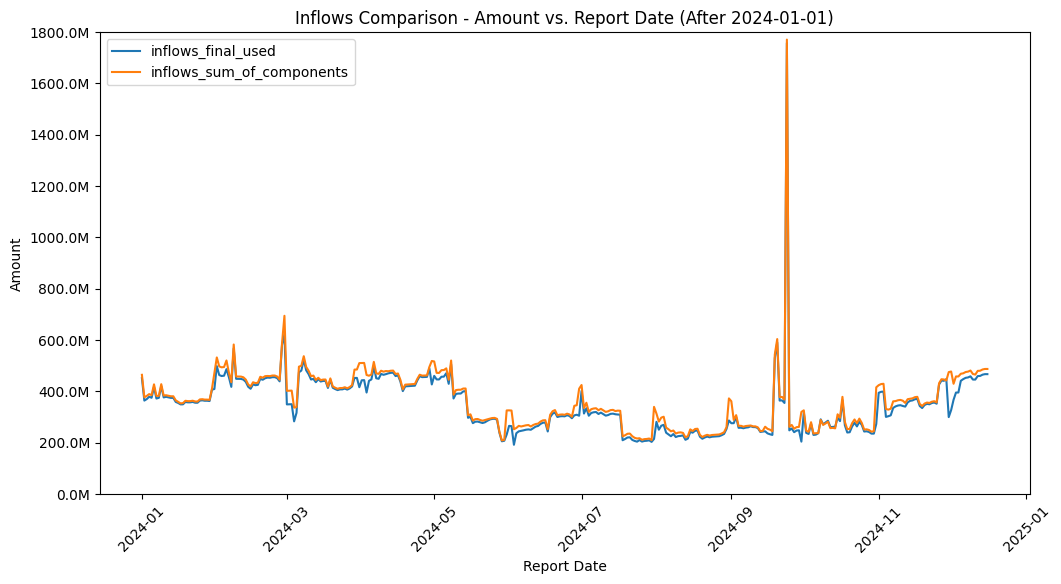

In [32]:
# Assuming your DataFrame is named 'df'
plt.figure(figsize=(12, 6))  # Adjust width and height as needed

merged_df7a_weighted['total'] = merged_df7b_weighted['amount_eur_weighted_x'] + merged_df7c_weighted['amount_eur_weighted_x']


sns.lineplot(x='report_dt', y='amount_eur_weighted_x', data=merged_df7a_weighted, label='inflows_final_used')

sns.lineplot(x='report_dt', y='total', data=merged_df7a_weighted, label='inflows_sum_of_components')
# sns.lineplot(x='report_dt', y='net_cash_outflow_weighted', data=merged_df7b_weighted, label='net cashflows ')

plt.title('Inflows Comparison - Amount vs. Report Date (After 2024-01-01)')
plt.xlabel('Report Date')
plt.ylabel('Amount')
plt.legend()
plt.xticks(rotation=45)

# Set y-axis limit to 10 million euros
plt.ylim(0, 1800000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

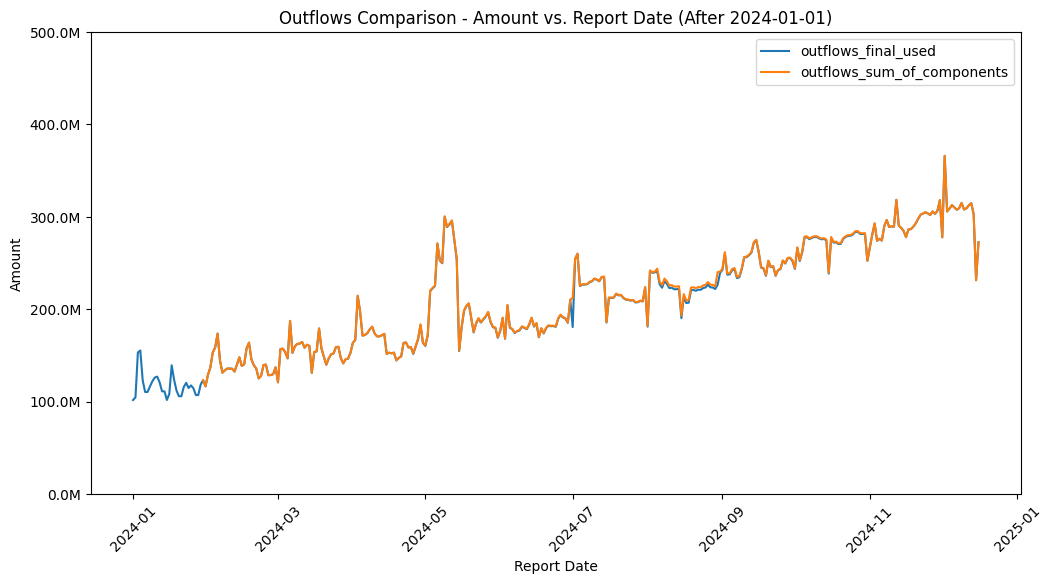

In [33]:
# Assuming your DataFrame is named 'df'
plt.figure(figsize=(12, 6))  # Adjust width and height as needed

merged_df7a_weighted['total_outflows'] = merged_df7b_weighted['amount_eur_weighted_y'] + merged_df7c_weighted['amount_eur_weighted_y']


sns.lineplot(x='report_dt', y='amount_eur_weighted_y', data=merged_df7a_weighted, label='outflows_final_used')

sns.lineplot(x='report_dt', y='total_outflows', data=merged_df7a_weighted, label='outflows_sum_of_components')
# sns.lineplot(x='report_dt', y='net_cash_outflow_weighted', data=merged_df7b_weighted, label='net cashflows ')

plt.title('Outflows Comparison - Amount vs. Report Date (After 2024-01-01)')
plt.xlabel('Report Date')
plt.ylabel('Amount')
plt.legend()
plt.xticks(rotation=45)

# Set y-axis limit to 10 million euros
plt.ylim(0, 500000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

#### Drill Down components 

In [34]:
sql_lcr_mapping = """
        SELECT lcr_template_mapping.account_id
            , lcr_template_mapping.be_id
            , lcr_template_mapping.sheet_name
            , lcr_template_mapping.row_name
            , lcr_template_mapping.customer
            , lcr_template_mapping.category_name
            , lcr_template_mapping.source_type
            , lcr_template_mapping.amount_type
            , lcr_template_mapping.group_account
            , lcr_template_mapping.id_type
            , lcr_template_mapping.end_date
            , lcr_template.item_name
            , lcr_template.standard_weight
        FROM teams_prd.risk_management_source.src__risk_management__lcr_template as lcr_template
        INNER JOIN teams_prd.risk_management_source.src__risk_management__lcr_template_mapping as lcr_template_mapping
            ON lcr_template.SHEET_NAME  = lcr_template_mapping.SHEET_NAME
                AND lcr_template.ROW_NAME = lcr_template_mapping.ROW_NAME
"""
df8 = db.run_query(query=sql_lcr_mapping)
df8.head(2)

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://traderepublic.okta.com/app/snowflake/exk18zobx3kssJFvx417/sso/saml?SAMLRequest=nZJPc9owEMW%2Fikc925KAYFcDZCgMlE5IGXDSTm%2FCFkS1LLlaGUM%2FfWX%2BdNJDcuhNI73d39O%2BHdwfSxUchAVp9BDRiKBA6MzkUu%2BH6CmdhQkKwHGdc2W0GKKTAHQ%2FGgAvVcXGtXvRa%2FGrFuAC30gDax%2BGqLaaGQ4SmOalAOYythkvH1gnIowDCOs8Dl1LcpCe9eJcxTBumiZqupGxe9whhGDyEXtVK%2FmAXiGq9xmVNc5kRt1Kjv5PbyAoJr0W4RWesLoWfpL6MoL3KNuLCNjnNF2Fq6%2BbFAXj2%2B8mRkNdCrsR9iAz8bR%2BuBgA72C%2B7CfdOI5EHWZCO8tVSCPQptkpXojMlFXtfOPIn%2FBO5FiZvfTjWkyHqCpknk82s%2BX3bTGZz4tDV5%2Fyhx5VcbqOl1kGP7fL59jefSuqPCFJhoLnW7idNtwFQC0Wuo3U%2BSvS6YW0E9J%2BSgkjfXZHIkqTHyiY%2Bkil5u5cefPtnebCiqreKplFpnD8bJFXFf7rHotjQZPfZnvsFgBfZodjj8YYwOA2N3RZHXa2YUf%2FMZABft3guoiPPpvFdGW8rVMwM7bk7u3oaETPNzIPd2cpEyWXapznVgD4CJUyzcQK7vy%2BO1sLhEcX

/Users/fgv/Documents/Coding/repos/risk_pylibrary/tools/snowflake_db/db_connection.py:179: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,account_id,be_id,sheet_name,row_name,customer,category_name,source_type,amount_type,group_account,id_type,end_date,item_name,standard_weight
0,10402090,30304,C 74.00.a,0130,None,Transit accounts,Booking_Engine,None,None,Ledger Platform Account,None,monies due from financial customers being clas...,0.05
1,10402090,30304,C 73.00.a,0150,None,Transit accounts,Booking_Engine,None,None,Ledger Platform Account,None,not covered by DGS,0.25


In [35]:
sql_sap_balances = """

WITH group_accounts AS (
        SELECT DISTINCT account_id, group_account
        FROM teams_prd.risk_management_source.src__risk_management__lcr_template_mapping
        WHERE group_account IS NOT NULL
    )
    , lcr_mapping AS (
        SELECT lcr_template_mapping.account_id
            , lcr_template_mapping.be_id
            , lcr_template_mapping.sheet_name
            , lcr_template_mapping.row_name
            , lcr_template_mapping.customer
            , lcr_template_mapping.category_name
            , lcr_template_mapping.source_type
            , lcr_template_mapping.amount_type
            , lcr_template_mapping.group_account
            , lcr_template_mapping.id_type
            , lcr_template_mapping.end_date
            , lcr_template.item_name
            , lcr_template.standard_weight
        FROM teams_prd.risk_management_source.src__risk_management__lcr_template as lcr_template
        INNER JOIN teams_prd.risk_management_source.src__risk_management__lcr_template_mapping as lcr_template_mapping
            ON lcr_template.SHEET_NAME  = lcr_template_mapping.SHEET_NAME
                AND lcr_template.ROW_NAME = lcr_template_mapping.ROW_NAME
    )
    , flipping_accounts AS (
        SELECT DISTINCT account_id
        FROM lcr_mapping
        GROUP BY account_id, customer
        HAVING COUNT(account_id) > 1
    )
    , data_union AS (
        SELECT sap.report_dt
            , sap.snapshot_dt
            , sap.amount_eur
            , sap.source_type
            , sap.amount_type
            , COALESCE(g_a.group_account, sap.account_id) AS account_id
            , sap.be_account_id
            , sap.customer
        FROM teams_prd.risk_management_transform.trf_curr__risk_management__sap_balances_30d AS sap
        LEFT JOIN group_accounts AS g_a
            ON g_a.account_id = sap.account_id
        WHERE (sap.be_account_id IS NULL -- Remove BE accounts to avoid double counting
            OR sap.be_account_id = '100000') -- BE account 100000 has strange balance behavior, needs investigation
    )

SELECT d_a.report_dt
    , d_a.snapshot_dt
    , d_a.amount_eur
    , (d_a.amount_eur * lcr_mapping.standard_weight) AS amount_eur_weighted
    , d_a.source_type
    , d_a.amount_type
    , d_a.account_id
    , d_a.be_account_id
    , d_a.customer
    , lcr_mapping.sheet_name
    , lcr_mapping.row_name
    , lcr_mapping.category_name
    , lcr_mapping.item_name
    , lcr_mapping.standard_weight
    , concat(
        d_a.source_type,
        '-',
        to_char(d_a.report_dt, 'yyyymmdd'),
        '-',
        ifnull(d_a.account_id, ''),
        '-',
        ifnull(d_a.customer, ''),
        '-',
        ifnull(d_a.amount_type, '')
    ) as surrogate_ky
    , current_timestamp() as _metadata__updated_at
FROM (
    /* Final aggregation to net out group accounts */
    SELECT report_dt
        , MAX(snapshot_dt) AS snapshot_dt
        , SUM(amount_eur) AS amount_eur
        , source_type
        , amount_type
        , account_id
        , be_account_id
        , customer
    FROM data_union
    GROUP BY ALL
) AS d_a
INNER JOIN lcr_mapping
    ON NVL(lcr_mapping.account_id,'0') = NVL(d_a.account_id,'0')
        AND NVL(lcr_mapping.be_id,'0') = NVL(d_a.be_account_id,'0')
        AND (lcr_mapping.customer IS NULL
            OR NVL(lcr_mapping.customer,'0') = NVL(d_a.customer,'0'))
        AND NVL(lcr_mapping.amount_type,'0') = NVL(d_a.amount_type,'0')
LEFT JOIN flipping_accounts AS f_a
    ON d_a.account_id = f_a.account_id
WHERE amount_eur <> 0
    /* Remove duplicate entries for accounts that can have both IN and OUT type
    but retain entries for non-flipping and other assets.
    */
    AND (
        (f_a.account_id IS NULL)
        OR (lcr_mapping.id_type = 'Other')
        OR (d_a.amount_eur > 0 AND lcr_mapping.sheet_name = 'C 74.00.a')
        OR (d_a.amount_eur < 0 AND lcr_mapping.sheet_name = 'C 73.00.a')
    )
    /* Only use mapped accounts until they were removed from RegRep */
    AND (lcr_mapping.end_date IS NULL OR lcr_mapping.end_date >= d_a.report_dt)
"""

sql_booking_engine_balance_30d = """

WITH group_accounts AS (
        SELECT DISTINCT account_id, group_account
        FROM teams_prd.risk_management_source.src__risk_management__lcr_template_mapping
        WHERE group_account IS NOT NULL
    )
    , lcr_mapping AS (
        SELECT lcr_template_mapping.account_id
            , lcr_template_mapping.be_id
            , lcr_template_mapping.sheet_name
            , lcr_template_mapping.row_name
            , lcr_template_mapping.customer
            , lcr_template_mapping.category_name
            , lcr_template_mapping.source_type
            , lcr_template_mapping.amount_type
            , lcr_template_mapping.group_account
            , lcr_template_mapping.id_type
            , lcr_template_mapping.end_date
            , lcr_template.item_name
            , lcr_template.standard_weight
        FROM teams_prd.risk_management_source.src__risk_management__lcr_template as lcr_template
        INNER JOIN teams_prd.risk_management_source.src__risk_management__lcr_template_mapping as lcr_template_mapping
            ON lcr_template.SHEET_NAME  = lcr_template_mapping.SHEET_NAME
                AND lcr_template.ROW_NAME = lcr_template_mapping.ROW_NAME
    )
    , flipping_accounts AS (
        SELECT DISTINCT account_id
        FROM lcr_mapping
        GROUP BY account_id, customer
        HAVING COUNT(account_id) > 1
    )
    , data_union AS (

        SELECT be.report_dt
            , be.snapshot_dt
            , be.amount_eur
            , be.source_type
            , be.amount_type
            , COALESCE(g_a.group_account, be.account_id) AS account_id
            /* Set BE ID to null if in group to allow for correct aggregation */
            , CASE WHEN g_a.group_account IS NOT NULL THEN NULL
                ELSE be.be_account_id
                END AS be_account_id
            , be.customer
        FROM teams_prd.risk_management_transform.trf_curr__risk_management__booking_engine_balances_30d AS be
        LEFT JOIN group_accounts AS g_a
            ON g_a.account_id = be.account_id
        GROUP BY ALL

    )

SELECT d_a.report_dt
    , d_a.snapshot_dt
    , d_a.amount_eur
    , (d_a.amount_eur * lcr_mapping.standard_weight) AS amount_eur_weighted
    , d_a.source_type
    , d_a.amount_type
    , d_a.account_id
    , d_a.be_account_id
    , d_a.customer
    , lcr_mapping.sheet_name
    , lcr_mapping.row_name
    , lcr_mapping.category_name
    , lcr_mapping.item_name
    , lcr_mapping.standard_weight
    , concat(
        d_a.source_type,
        '-',
        to_char(d_a.report_dt, 'yyyymmdd'),
        '-',
        ifnull(d_a.account_id, ''),
        '-',
        ifnull(d_a.customer, ''),
        '-',
        ifnull(d_a.amount_type, '')
    ) as surrogate_ky
    , current_timestamp() as _metadata__updated_at
FROM (
    /* Final aggregation to net out group accounts */
    SELECT report_dt
        , MAX(snapshot_dt) AS snapshot_dt
        , SUM(amount_eur) AS amount_eur
        , source_type
        , amount_type
        , account_id
        , be_account_id
        , customer
    FROM data_union
    GROUP BY ALL
) AS d_a
INNER JOIN lcr_mapping
    ON NVL(lcr_mapping.account_id,'0') = NVL(d_a.account_id,'0')
        AND NVL(lcr_mapping.be_id,'0') = NVL(d_a.be_account_id,'0')
        AND (lcr_mapping.customer IS NULL
            OR NVL(lcr_mapping.customer,'0') = NVL(d_a.customer,'0'))
        AND NVL(lcr_mapping.amount_type,'0') = NVL(d_a.amount_type,'0')
LEFT JOIN flipping_accounts AS f_a
    ON d_a.account_id = f_a.account_id
WHERE amount_eur <> 0
    /* Remove duplicate entries for accounts that can have both IN and OUT type
    but retain entries for non-flipping and other assets.
    */
    AND (
        (f_a.account_id IS NULL)
        OR (lcr_mapping.id_type = 'Other')
        OR (d_a.amount_eur > 0 AND lcr_mapping.sheet_name = 'C 74.00.a')
        OR (d_a.amount_eur < 0 AND lcr_mapping.sheet_name = 'C 73.00.a')
    )
    /* Only use mapped accounts until they were removed from RegRep */
    AND (lcr_mapping.end_date IS NULL OR lcr_mapping.end_date >= d_a.report_dt)
"""

sqla_interest_accruals = """ 

 
WITH group_accounts AS (
        SELECT DISTINCT account_id, group_account
        FROM teams_prd.risk_management_source.src__risk_management__lcr_template_mapping
        WHERE group_account IS NOT NULL
    )
    , lcr_mapping AS (
        SELECT lcr_template_mapping.account_id
            , lcr_template_mapping.be_id
            , lcr_template_mapping.sheet_name
            , lcr_template_mapping.row_name
            , lcr_template_mapping.customer
            , lcr_template_mapping.category_name
            , lcr_template_mapping.source_type
            , lcr_template_mapping.amount_type
            , lcr_template_mapping.group_account
            , lcr_template_mapping.id_type
            , lcr_template_mapping.end_date
            , lcr_template.item_name
            , lcr_template.standard_weight
        FROM teams_prd.risk_management_source.src__risk_management__lcr_template as lcr_template
        INNER JOIN teams_prd.risk_management_source.src__risk_management__lcr_template_mapping as lcr_template_mapping
            ON lcr_template.SHEET_NAME  = lcr_template_mapping.SHEET_NAME
                AND lcr_template.ROW_NAME = lcr_template_mapping.ROW_NAME
    )
    , flipping_accounts AS (
        SELECT DISTINCT account_id
        FROM lcr_mapping
        GROUP BY account_id, customer
        HAVING COUNT(account_id) > 1
    )
    , data_union AS (
        SELECT report_dt
            , snapshot_dt
            , amount_eur   
            , source_type
            , amount_type
            , account_id
            , NULL AS be_account_id
            , customer
        FROM teams_prd.risk_management_transform.trf_snapshot__risk_management__interest_accruals
        GROUP BY ALL


    )

SELECT d_a.report_dt
    , d_a.snapshot_dt
    , d_a.amount_eur
    , (d_a.amount_eur * lcr_mapping.standard_weight) AS amount_eur_weighted
    , d_a.source_type
    , d_a.amount_type
    , d_a.account_id
    , d_a.be_account_id
    , d_a.customer
    , lcr_mapping.sheet_name
    , lcr_mapping.row_name
    , lcr_mapping.category_name
    , lcr_mapping.item_name
    , lcr_mapping.standard_weight
    , concat(
        d_a.source_type,
        '-',
        to_char(d_a.report_dt, 'yyyymmdd'),
        '-',
        ifnull(d_a.account_id, ''),
        '-',
        ifnull(d_a.customer, ''),
        '-',
        ifnull(d_a.amount_type, '')
    ) as surrogate_ky
    , current_timestamp() as _metadata__updated_at
FROM (
    /* Final aggregation to net out group accounts */
    SELECT report_dt
        , MAX(snapshot_dt) AS snapshot_dt
        , SUM(amount_eur) AS amount_eur
        , source_type
        , amount_type
        , account_id
        , be_account_id
        , customer
    FROM data_union
    GROUP BY ALL
) AS d_a
INNER JOIN lcr_mapping
    ON NVL(lcr_mapping.account_id,'0') = NVL(d_a.account_id,'0')
        AND NVL(lcr_mapping.be_id,'0') = NVL(d_a.be_account_id,'0')
        AND (lcr_mapping.customer IS NULL
            OR NVL(lcr_mapping.customer,'0') = NVL(d_a.customer,'0'))
        AND NVL(lcr_mapping.amount_type,'0') = NVL(d_a.amount_type,'0')
LEFT JOIN flipping_accounts AS f_a
    ON d_a.account_id = f_a.account_id
WHERE amount_eur <> 0
    /* Remove duplicate entries for accounts that can have both IN and OUT type
    but retain entries for non-flipping and other assets.
    */
    AND (
        (f_a.account_id IS NULL)
        OR (lcr_mapping.id_type = 'Other')
        OR (d_a.amount_eur > 0 AND lcr_mapping.sheet_name = 'C 74.00.a')
        OR (d_a.amount_eur < 0 AND lcr_mapping.sheet_name = 'C 73.00.a')
    )
    /* Only use mapped accounts until they were removed from RegRep */
    AND (lcr_mapping.end_date IS NULL OR lcr_mapping.end_date >= d_a.report_dt)

    """

df10 = db.run_query(query=sql_sap_balances)
df11 = db.run_query(query=sql_booking_engine_balance_30d)
df12 = db.run_query(query=sqla_interest_accruals)


Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://traderepublic.okta.com/app/snowflake/exk18zobx3kssJFvx417/sso/saml?SAMLRequest=nZJPc5swEMW%2FCqOeQQi74GpsZ2g8bpxJUjd2mrY3AbKjICSiFWD301f4Tyc9JIfeNNLb%2FT3t2%2FHFrpJeyw0IrSaIBCHyuMp1IdR2gh7Wc3%2BEPLBMFUxqxSdozwFdTMfAKlnTtLFP6p6%2FNBys5xopoP3DBDVGUc1AAFWs4kBtTlfp7Q2NgpAyAG6sw6FTSQHCsZ6srSnGXdcF3SDQZoujMAxx%2BAk7VS%2F5gF4h6vcZtdFW51qeS3buT28gCA6HPcIpHGF5Kvws1HEE71Gyowjo1Xq99JdfV2vkpeffXWoFTcXNiptW5Pzh%2FuZoAJyDL7fxaJAkAW%2F8nCtrmPRJAEp3G8lKnuuqbqxrHLgT3vACS70VblyL2QTVpShUZ20Ux0n6fN22pNyncQuPP74VbfZIXlp21VRJ1qrnnxlsc%2BR9P4cb9eEuABq%2BUH2k1l2F0dAnkU%2FiNQlpGNOPUZAM41%2FIm7lIhWL2UHn27ZwW3PC6yaTIA11adrDI6hr%2FdY%2F5riSj3zrbDUqA63m7G5IEA2jc54aOq0MPNsz0PwYyxq8bnBbxzmWzmC21s7X35tpUzL4dHQnI4UYU%2FuYgpbxiQqZFYTiAi1BK3V0azqzbd2sajvD0SP1346d%2FAA

/Users/fgv/Documents/Coding/repos/risk_pylibrary/tools/snowflake_db/db_connection.py:179: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://traderepublic.okta.com/app/snowflake/exk18zobx3kssJFvx417/sso/saml?SAMLRequest=nZJbc9owEIX%2Fikd9tiUZCkQDZCiU1J2QEi7pTN%2BEJRyBLblaGZP8%2BspcOulD8tA3jXR2v6M92789FnlwkBaU0QNEI4ICqVMjlM4GaL2ahj0UgONa8NxoOUAvEtDtsA%2B8yEs2qtyzXsjflQQX%2BEYaWPMwQJXVzHBQwDQvJDCXsuVods%2FiiDAOIK3zOHQpEaA869m5kmFc13VUtyJjMxwTQjC5wV7VSD6hN4jyY0ZpjTOpya8lR%2F%2BndxAUk3aD8ApPmF8Kvyh9HsFHlM1ZBOzbajUP5z%2BWKxSMrr8bGw1VIe1S2oNK5XpxfzYA3sHdrNNrdbuRrMJUamd5HtIItKm3Od%2FL1BRl5XzjyJ%2FwVgqcm0z5cSWTASr3StAnsd5tEzHKEvKwttNW1vua3GU7uhCT8eKnmSVrznf68TGGFAVP13DjJtwEoJKJbiJ1%2ForE7ZDGIe2sKGGkwz53oxtKf6Fg4iNVmrtT5dW3dyqklWW1yVUamb3jJ4u8LPFf91ge97T3ajbH1h7g%2B%2FRwbNMuBjC4yQ2dV4edbNjhfwykj982uCzig88mmcyNt%2FUSTI0tuHs%2FOhrR040S4fYkZbLgKh8JYSWAjzDPTT22kju%2F785WEuHhmfrvxg%2F%

/Users/fgv/Documents/Coding/repos/risk_pylibrary/tools/snowflake_db/db_connection.py:179: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://traderepublic.okta.com/app/snowflake/exk18zobx3kssJFvx417/sso/saml?SAMLRequest=nZJPb%2BIwEMW%2FSuQ9J05CBKwFVLSIXVZQopKuqr2ZZKCGxE49Dgl8%2Bjr8WXUP7WFvlv1mfs%2FzZnDXFLlzAI1CySEJPJ84IFOVCbkdkudk6vaJg4bLjOdKwpAcAcndaIC8yEs2rsyrfIK3CtA4tpFE1j4MSaUlUxwFMskLQGZSthov5iz0fMYRQRuLI9eSDIVlvRpTMkrruvbqjqf0loa%2B71P%2FO7WqVvKNfECUXzNKrYxKVX4raeyfPkEE1I9ahFVYQnwtvBfyMoKvKOuLCNnPJIndeLlKiDO%2B%2Fe5BSawK0CvQB5HC89P8YgCtgx%2BLbr%2FT63lQuSlIo3nuBh5KVW9yvodUFWVlbGPPnugGMpqrrbDjmk2GpNyLLOqLGt6WzfzlcZHFL91kF%2BFxfD%2Ft7bbLU8XDddoNo504FX1MifP7Fm7YhjtDrGAm20iNvfLDyA1CN%2Bgmgc%2F8HvOtKAz%2BEGdiIxWSm3Plzbd1moGGslrnIvXU3vCzRV6W9K97Cs0%2B6J%2FUuunsEX9ND00U9Ciiom1u5LI67GxDj%2F5jIAP6scF1ER9tNrNJrKytozNVuuDm8%2BgCLzjfiMzdnKUMCi7ycZZpQLQR5rmqHzRwY%2Ffd6AoIHV2o%2F2

/Users/fgv/Documents/Coding/repos/risk_pylibrary/tools/snowflake_db/db_connection.py:179: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [36]:
# Filter data for report dates after 01/01/2024
cutoff_date = datetime(2023, 12, 5).date()
df10_filtered = df10[df10['report_dt'] >= cutoff_date]
df11_filtered = df11[df11['report_dt'] >= cutoff_date]
df12_filtered = df12[df12['report_dt'] >= cutoff_date]


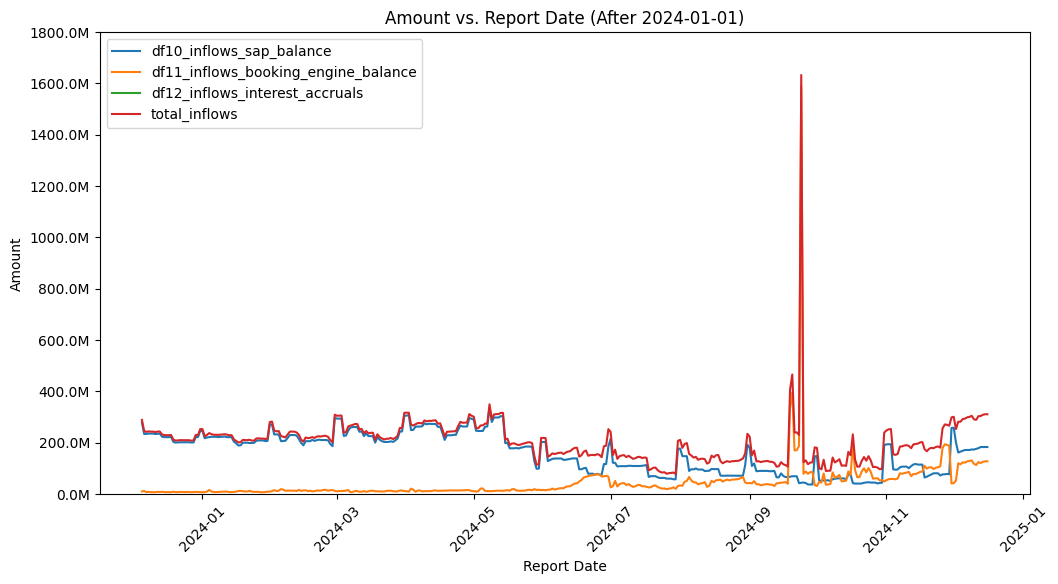

In [37]:
# Assuming your DataFrame is named 'df'
plt.figure(figsize=(12, 6))  # Adjust width and height as needed

# Filter inflows and outflows
df10_inflows = df10_filtered[df10_filtered['sheet_name'] == 'C 74.00.a'].groupby('report_dt')[['amount_eur_weighted']].sum().reset_index()
df11_inflows = df11_filtered[df11_filtered['sheet_name'] == 'C 74.00.a'].groupby('report_dt')[['amount_eur_weighted']].sum().reset_index()
df12_inflows = df12_filtered[df12_filtered['sheet_name'] == 'C 74.00.a'].groupby('report_dt')[['amount_eur_weighted']].sum().reset_index()

merged_inflows_df_base = pd.merge(df10_inflows, df11_inflows, on='report_dt', how='outer')
merged_inflows_df = pd.merge(merged_inflows_df_base, df12_inflows, on='report_dt', how='outer')
merged_inflows_df['total_inflows'] = merged_inflows_df['amount_eur_weighted_x'] + merged_inflows_df['amount_eur_weighted_y']


sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df10_inflows, label='df10_inflows_sap_balance')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_inflows, label='df11_inflows_booking_engine_balance')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df12_inflows, label='df12_inflows_interest_accruals')
sns.lineplot(x='report_dt', y='total_inflows', data=merged_inflows_df, label='total_inflows')


plt.title('Amount vs. Report Date (After 2024-01-01)')
plt.xlabel('Report Date')
plt.ylabel('Amount')
plt.legend()
plt.xticks(rotation=45)
plt.ylim(0, 1800000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

In [38]:
df11[(df11['sheet_name'] == 'C 74.00.a') & (df11['report_dt']== datetime(2024,9,24).date()) & (df11['amount_eur']> 1000000000)]


,report_dt,snapshot_dt,amount_eur,amount_eur_weighted,source_type,amount_type,account_id,be_account_id,customer,sheet_name,row_name,category_name,item_name,standard_weight,surrogate_ky,_metadata__updated_at
21810,2024-09-24,2024-12-16 08:26:43.440000+00:00,1.510705e+09,1.510705e+09,Booking_Engine,None,10225020,30450,None,C 74.00.a,0160,Transit accounts,monies due from other financial customers,1.0,Booking_Engine-20240924-10225020--,2024-12-16 10:07:00.108000+00:00


In [39]:
set(df10[(df10['sheet_name'] == 'C 74.00.a')]['item_name'])

{'monies due from assets with an undefined contractual end date',
 'monies due from central banks',
 'monies due from other financial customers',
 'monies due from other legal entities',
 'monies due from sovereigns, multilateral development banks and public sector entities'}

In [40]:
# # Assuming your DataFrame is named 'df'
# plt.figure(figsize=(12, 6))  # Adjust width and height as needed

# df11_inflows_item_name = df11_filtered[df11_filtered['sheet_name'] == 'C 74.00.a'].groupby(['report_dt','item_name'])[['amount_eur_weighted']].sum().reset_index()

# # Filter inflows and outflows
# df11_inflows_assets_undefined_date = df11_filtered[df11_filtered['item_name'] == 'monies due from assets with an undefined contractual end date'].groupby('report_dt',)[['amount_eur_weighted']].sum().reset_index()
# df11_inflows_central_banks = df11_filtered[df11_filtered['item_name'] == 'monies due from central banks'].groupby('report_dt',)[['amount_eur_weighted']].sum().reset_index()
# df11_inflows_fin_customers = df11_filtered[df11_filtered['item_name'] == 'monies due from other financial customers'].groupby('report_dt',)[['amount_eur_weighted']].sum().reset_index()
# df11_inflows_other_legal = df11_filtered[df11_filtered['item_name'] == 'monies due from other legal entities'].groupby('report_dt',)[['amount_eur_weighted']].sum().reset_index()
# df11_inflows_sov_dev_banks = df11_filtered[df11_filtered['item_name'] == 'monies due from sovereigns, multilateral development banks and public sector entities'].groupby('report_dt',)[['amount_eur_weighted']].sum().reset_index()

# sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_inflows_assets_undefined_date, label='df11_inflows_assets_undefined_date')
# sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_inflows_central_banks, label='df11_inflows_central_banks')
# sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_inflows_fin_customers, label='df11_inflows_fin_customers')
# sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_inflows_other_legal, label='df11_inflows_other_legal')
# sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_inflows_sov_dev_banks, label='df11_inflows_sov_dev_banks')

# plt.title('Booking engine Amount vs. Report Date (After 2024-01-01)')
# plt.xlabel('Report Date')
# plt.ylabel('Amount')
# plt.legend()
# plt.xticks(rotation=45)
# plt.show()

In [41]:
set(df11_filtered[(df11_filtered['sheet_name'] == 'C 74.00.a')]['item_name'])

{'monies due from financial customers being classified as operational deposits where the credit institution is not able to establish a corresponding symmetrical inflow rate',
 'monies due from other financial customers',
 'monies due from other legal entities',
 'monies due from sovereigns, multilateral development banks and public sector entities'}

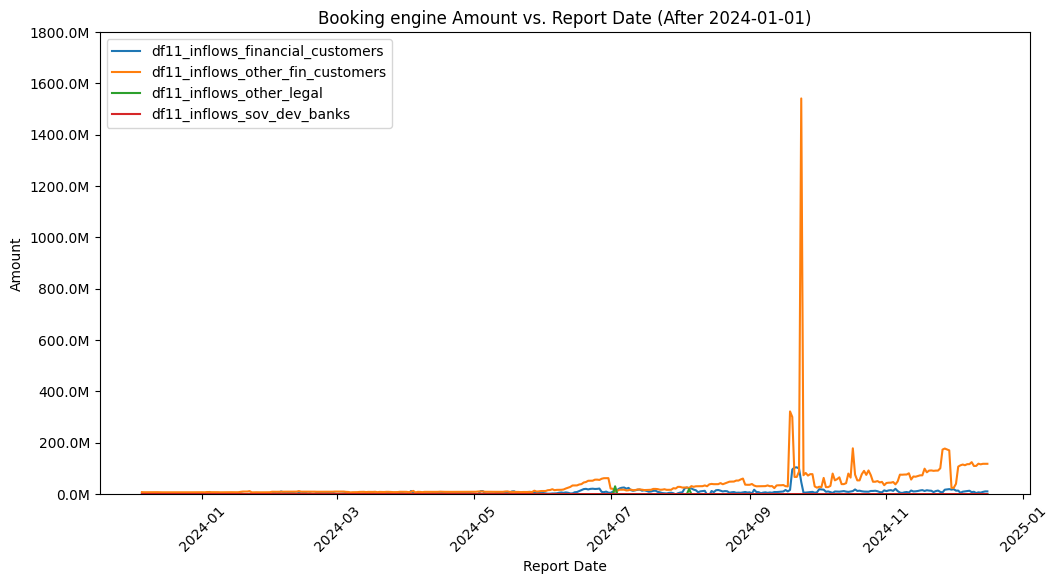

In [42]:
# Assuming your DataFrame is named 'df'
plt.figure(figsize=(12, 6))  # Adjust width and height as needed


df11_inflows_item_name = df11_filtered[df11_filtered['sheet_name'] == 'C 74.00.a'].groupby(['report_dt','item_name'])[['amount_eur_weighted']].sum().reset_index()

# Filter inflows and outflows
df11_inflows_financial_customers = df11_filtered[df11_filtered['item_name'] == 'monies due from financial customers being classified as operational deposits where the credit institution is not able to establish a corresponding symmetrical inflow rate'].groupby('report_dt',)[['amount_eur_weighted']].sum().reset_index()
# df11_inflows_central_banks = df11_filtered[df11_filtered['item_name'] == 'monies due from central banks'].groupby('report_dt',)[['amount_eur_weighted']].sum().reset_index()
df11_inflows_fin_customers = df11_filtered[df11_filtered['item_name'] == 'monies due from other financial customers'].groupby('report_dt',)[['amount_eur_weighted']].sum().reset_index()
df11_inflows_other_legal = df11_filtered[df11_filtered['item_name'] == 'monies due from other legal entities'].groupby('report_dt',)[['amount_eur_weighted']].sum().reset_index()
df11_inflows_sov_dev_banks = df11_filtered[df11_filtered['item_name'] == 'monies due from sovereigns, multilateral development banks and public sector entities'].groupby('report_dt',)[['amount_eur_weighted']].sum().reset_index()

sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_inflows_financial_customers, label='df11_inflows_financial_customers')
# sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_inflows_central_banks, label='df11_inflows_central_banks')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_inflows_fin_customers, label='df11_inflows_other_fin_customers')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_inflows_other_legal, label='df11_inflows_other_legal')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_inflows_sov_dev_banks, label='df11_inflows_sov_dev_banks')

plt.title('Booking engine Amount vs. Report Date (After 2024-01-01)')
plt.xlabel('Report Date')
plt.ylabel('Amount')
plt.legend()
plt.xticks(rotation=45)
plt.ylim(0, 1800000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

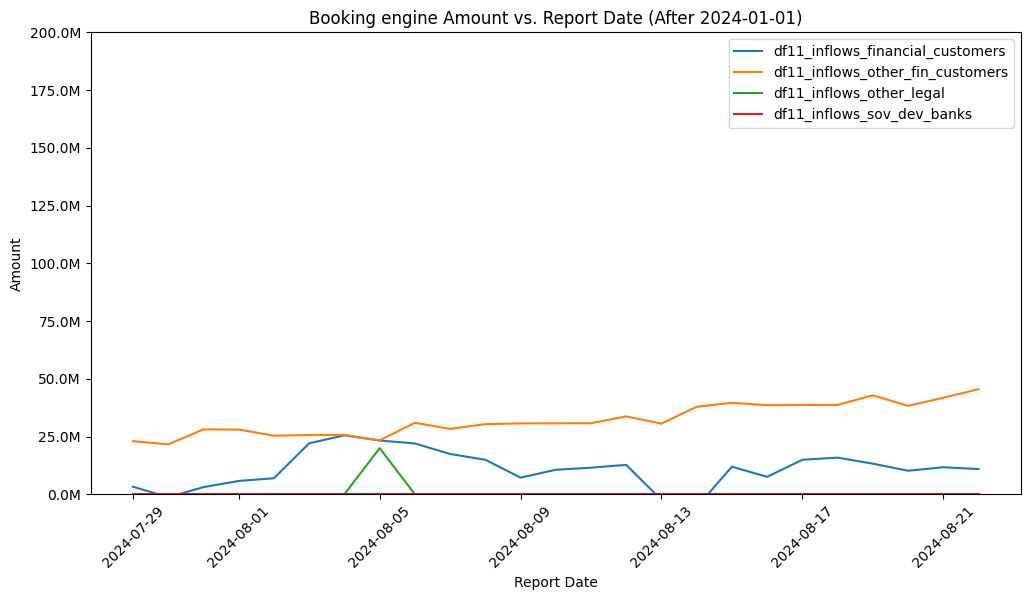

In [62]:
# Assuming your DataFrame is named 'df'
plt.figure(figsize=(12, 6))  # Adjust width and height as needed

# Filter data for the last month
start_date = datetime(2024,7,29).date()
stop_date = datetime(2024,8,23).date()



df11_inflows_item_name = df11_filtered[df11_filtered['sheet_name'] == 'C 74.00.a'].groupby(['report_dt','item_name'])[['amount_eur_weighted']].sum().reset_index()

# Filter inflows and outflows
df11_inflows_financial_customers = df11_filtered[df11_filtered['item_name'] == 'monies due from financial customers being classified as operational deposits where the credit institution is not able to establish a corresponding symmetrical inflow rate'].groupby('report_dt',)[['amount_eur_weighted']].sum().reset_index()
# df11_inflows_central_banks = df11_filtered[df11_filtered['item_name'] == 'monies due from central banks'].groupby('report_dt',)[['amount_eur_weighted']].sum().reset_index()
df11_inflows_fin_customers = df11_filtered[df11_filtered['item_name'] == 'monies due from other financial customers'].groupby('report_dt',)[['amount_eur_weighted']].sum().reset_index()
df11_inflows_other_legal = df11_filtered[df11_filtered['item_name'] == 'monies due from other legal entities'].groupby('report_dt',)[['amount_eur_weighted']].sum().reset_index()
df11_inflows_sov_dev_banks = df11_filtered[df11_filtered['item_name'] == 'monies due from sovereigns, multilateral development banks and public sector entities'].groupby('report_dt',)[['amount_eur_weighted']].sum().reset_index()

sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_inflows_financial_customers[(df11_inflows_financial_customers['report_dt'] >= start_date) & (df11_inflows_financial_customers['report_dt'] < stop_date) ], label='df11_inflows_financial_customers')
# sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_inflows_central_banks, label='df11_inflows_central_banks')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_inflows_fin_customers[(df11_inflows_fin_customers['report_dt'] >= start_date) & (df11_inflows_fin_customers['report_dt'] < stop_date) ], label='df11_inflows_other_fin_customers')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_inflows_other_legal[(df11_inflows_other_legal['report_dt'] >= start_date) & (df11_inflows_other_legal['report_dt'] < stop_date) ], label='df11_inflows_other_legal')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_inflows_sov_dev_banks[(df11_inflows_sov_dev_banks['report_dt'] >= start_date) & (df11_inflows_sov_dev_banks['report_dt'] < stop_date) ], label='df11_inflows_sov_dev_banks')

plt.title('Booking engine Amount vs. Report Date (After 2024-01-01)')
plt.xlabel('Report Date')
plt.ylabel('Amount')
plt.legend()
plt.xticks(rotation=45)
plt.ylim(0, 200000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

In [43]:
merged_inflows_df[merged_inflows_df['report_dt'] == datetime(2024,9,24).date()]

,report_dt,amount_eur_weighted_x,amount_eur_weighted_y,amount_eur_weighted,total_inflows
294,2024-09-24,4.411436e+07,1.588528e+09,NaN,1.632642e+09


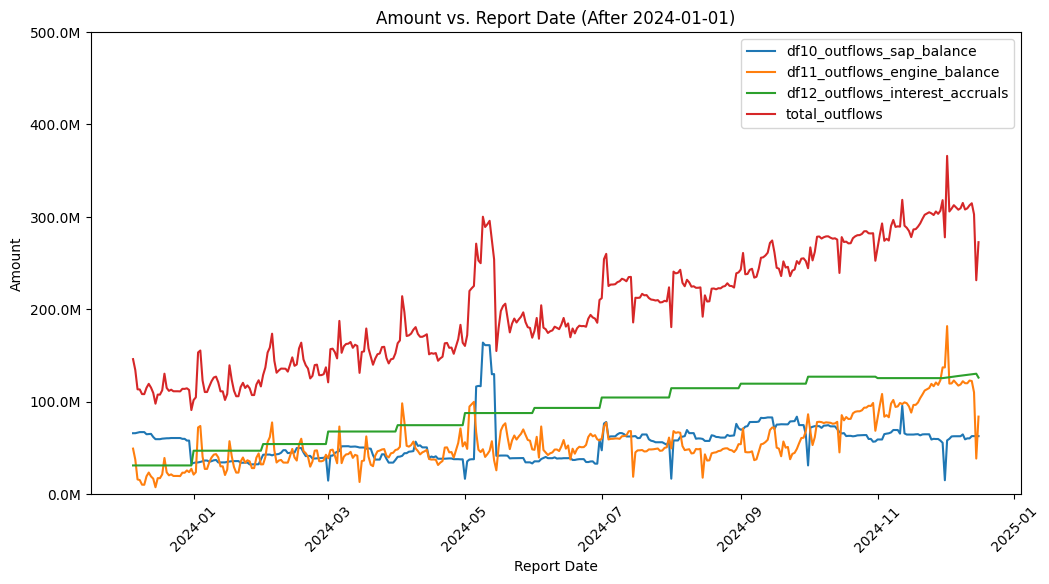

In [44]:
# Assuming your DataFrame is named 'df'
plt.figure(figsize=(12, 6))  # Adjust width and height as needed

# Filter inflows and outflows
df10_outflows = df10_filtered[df10_filtered['sheet_name'] == 'C 73.00.a'].groupby('report_dt').agg({'amount_eur_weighted': lambda x: x.abs().sum()}).reset_index()# Merge DataFrames on 'report_dt'
df11_outflows = df11_filtered[df11_filtered['sheet_name'] == 'C 73.00.a'].groupby('report_dt').agg({'amount_eur_weighted': lambda x: x.abs().sum()}).reset_index()# Merge DataFrames on 'report_dt'
df12_outflows = df12_filtered[df12_filtered['sheet_name'] == 'C 73.00.a'].groupby('report_dt').agg({'amount_eur_weighted': lambda x: x.abs().sum()}).reset_index()# Merge DataFrames on 'report_dt'

merged_outflows_df_base = pd.merge(df10_outflows, df11_outflows, on='report_dt', how='outer')
merged_outflows_df = pd.merge(merged_outflows_df_base, df12_outflows, on='report_dt', how='outer')
merged_outflows_df['total_outflows'] = merged_outflows_df['amount_eur_weighted_x'] + merged_outflows_df['amount_eur_weighted_y']+ merged_outflows_df['amount_eur_weighted']



sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df10_outflows, label='df10_outflows_sap_balance')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_outflows, label='df11_outflows_engine_balance')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df12_outflows, label='df12_outflows_interest_accruals')
sns.lineplot(x='report_dt', y='total_outflows', data=merged_outflows_df, label='total_outflows')

plt.title('Amount vs. Report Date (After 2024-01-01)')
plt.xlabel('Report Date')
plt.ylabel('Amount')
plt.legend()
plt.xticks(rotation=45)
plt.ylim(0, 500000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

In [45]:
merged_outflows_df[merged_outflows_df['report_dt'] == datetime(2024,5,9).date()]

,report_dt,amount_eur_weighted_x,amount_eur_weighted_y,amount_eur_weighted,total_outflows
156,2024-05-09,1.639517e+08,4.850928e+07,8.769675e+07,3.001577e+08


In [46]:
df11_deepdive = df11_filtered[df11_filtered['sheet_name'] == 'C 73.00.a'].sort_values(by='report_dt', ascending=False)
df11_deepdive.head(2)

,report_dt,snapshot_dt,amount_eur,amount_eur_weighted,source_type,amount_type,account_id,be_account_id,customer,sheet_name,row_name,category_name,item_name,standard_weight,surrogate_ky,_metadata__updated_at
36903,2024-12-16,2024-12-16 08:26:43.440000+00:00,-62600.8,-15650.2,Booking_Engine,None,10402041,150210,None,C 73.00.a,0150,Transit accounts,not covered by DGS,0.25,Booking_Engine-20241216-10402041--,2024-12-16 10:07:00.108000+00:00
52034,2024-12-16,2024-12-16 08:26:43.440000+00:00,-283189.2,-70797.3,SAP_Booking_Engine,None,10402001,120200,None,C 73.00.a,0150,Settlement accounts,not covered by DGS,0.25,SAP_Booking_Engine-20241216-10402001--,2024-12-16 10:07:00.108000+00:00


In [47]:
set(df11_deepdive['category_name'])

{'Bank accounts',
 'Monthly taxes with 10 days delay',
 'Monthly taxes with 15 days delay',
 'Settlement accounts',
 'Tax Liabilities',
 'Transit accounts',
 'Weekly taxes with 4 days delay'}

In [48]:
df11_1 = df11_deepdive[df11_deepdive['category_name']== 'Bank accounts'].groupby('report_dt').agg({'amount_eur_weighted': lambda x: x.abs().sum()}).reset_index()
df11_2 = df11_deepdive[df11_deepdive['category_name']== 'Monthly taxes with 10 days delay'].groupby('report_dt').agg({'amount_eur_weighted': lambda x: x.abs().sum()}).reset_index()
df11_3 = df11_deepdive[df11_deepdive['category_name']== 'Monthly taxes with 15 days delay'].groupby('report_dt').agg({'amount_eur_weighted': lambda x: x.abs().sum()}).reset_index()
df11_4 = df11_deepdive[df11_deepdive['category_name']== 'Settlement accounts'].groupby('report_dt').agg({'amount_eur_weighted': lambda x: x.abs().sum()}).reset_index()
df11_5 = df11_deepdive[df11_deepdive['category_name']== 'Tax Liabilities'].groupby('report_dt').agg({'amount_eur_weighted': lambda x: x.abs().sum()}).reset_index()
df11_6 = df11_deepdive[df11_deepdive['category_name']== 'Transit accounts'].groupby('report_dt').agg({'amount_eur_weighted': lambda x: x.abs().sum()}).reset_index()
df11_7 = df11_deepdive[df11_deepdive['category_name']== 'Weekly taxes with 4 days delay'].groupby('report_dt').agg({'amount_eur_weighted': lambda x: x.abs().sum()}).reset_index()

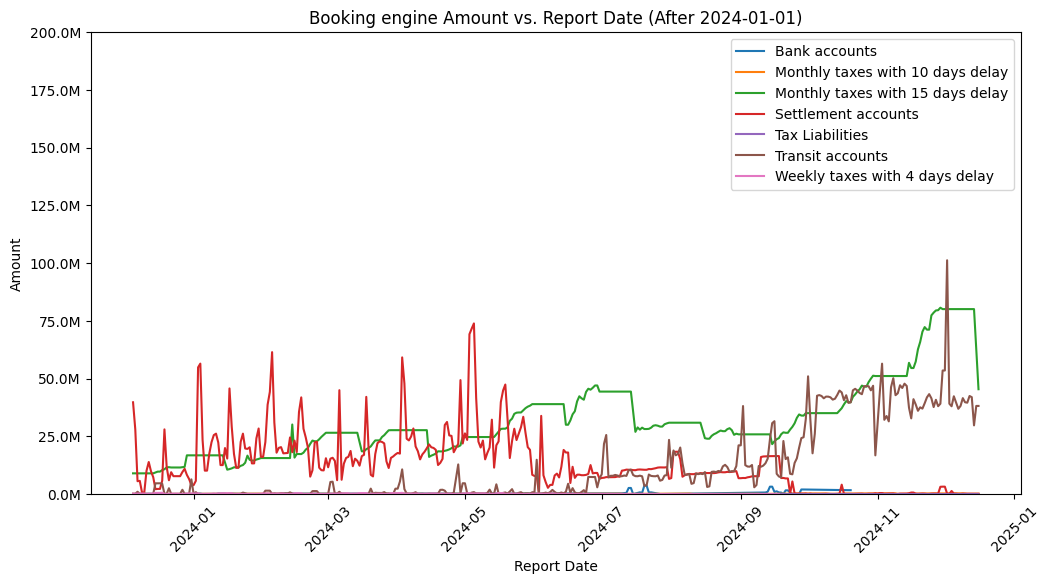

In [49]:
 
# Assuming your DataFrame is named 'df'
plt.figure(figsize=(12, 6))  # Adjust width and height as needed


sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_1, label='Bank accounts')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_2, label='Monthly taxes with 10 days delay')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_3, label='Monthly taxes with 15 days delay')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_4, label='Settlement accounts')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_5, label='Tax Liabilities')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_6, label='Transit accounts')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_7, label='Weekly taxes with 4 days delay')



plt.title('Booking engine Amount vs. Report Date (After 2024-01-01)')
plt.xlabel('Report Date')
plt.ylabel('Amount')
plt.legend()
plt.xticks(rotation=45)
plt.ylim(0, 200000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

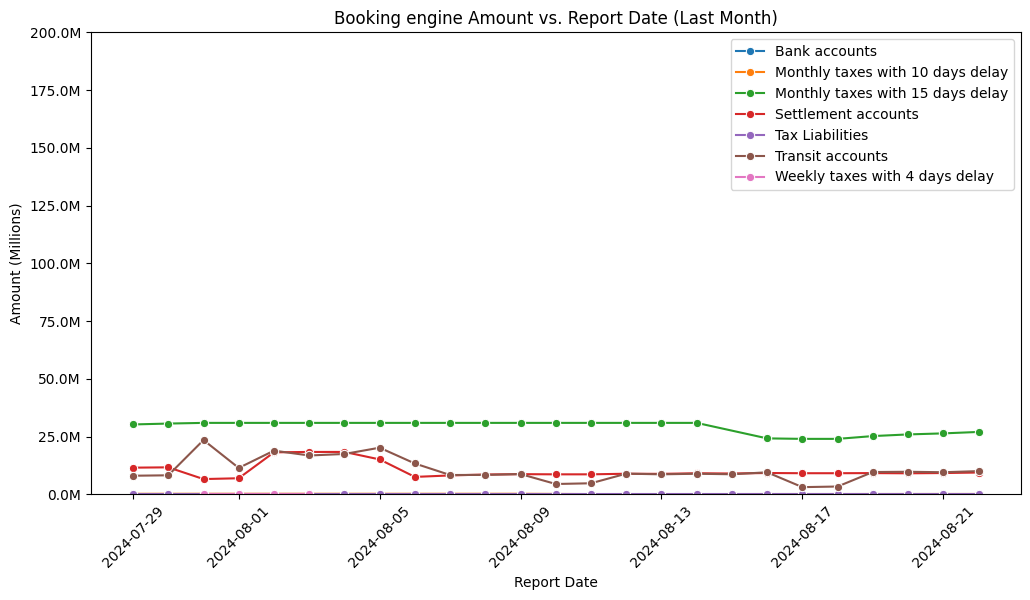

In [60]:


# Assuming you have DataFrames df11_1, df11_2, ..., df11_7

# Filter data for the last month
start_date = datetime(2024,7,29).date()
stop_date = datetime(2024,8,23).date()


# Filter each DataFrame for the last month
df11_1_filtered = df11_1[(df11_1['report_dt'] >= start_date) & (df11_1['report_dt'] < stop_date) ]
df11_2_filtered = df11_2[(df11_2['report_dt'] >= start_date) & (df11_2['report_dt'] < stop_date) ]
df11_3_filtered = df11_3[(df11_3['report_dt'] >= start_date) & (df11_3['report_dt'] < stop_date)]
df11_4_filtered = df11_4[(df11_4['report_dt'] >= start_date) & (df11_4['report_dt'] < stop_date)]
df11_5_filtered = df11_5[(df11_5['report_dt'] >= start_date) & (df11_5['report_dt'] < stop_date)]
df11_6_filtered = df11_6[(df11_6['report_dt'] >= start_date) & (df11_6['report_dt'] < stop_date)]
df11_7_filtered = df11_7[(df11_7['report_dt'] >= start_date) & (df11_7['report_dt'] < stop_date)]

# Create the plot
plt.figure(figsize=(12, 6))

# Plot the filtered data with markers
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_1_filtered, marker='o', label='Bank accounts')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_2_filtered, marker='o', label='Monthly taxes with 10 days delay')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_3_filtered, marker='o', label='Monthly taxes with 15 days delay')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_4_filtered, marker='o', label='Settlement accounts')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_5_filtered, marker='o', label='Tax Liabilities')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_6_filtered, marker='o', label='Transit accounts')
sns.lineplot(x='report_dt', y='amount_eur_weighted', data=df11_7_filtered, marker='o', label='Weekly taxes with 4 days delay')

# Customize the plot
plt.title('Booking engine Amount vs. Report Date (Last Month)')
plt.xlabel('Report Date')
plt.ylabel('Amount (Millions)')
plt.legend()
plt.xticks(rotation=45)
plt.ylim(0, 200000000)
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

In [51]:
set(df11_deepdive['item_name'])

{'deposits by financial customers', 'not covered by DGS', 'others'}

In [52]:
sql_query_cashflows = """
WITH group_accounts AS (
        SELECT DISTINCT account_id, group_account
        FROM teams_prd.risk_management_source.src__risk_management__lcr_template_mapping
        WHERE group_account IS NOT NULL
    )
    , lcr_mapping AS (
        SELECT lcr_template_mapping.account_id
            , lcr_template_mapping.be_id
            , lcr_template_mapping.sheet_name
            , lcr_template_mapping.row_name
            , lcr_template_mapping.customer
            , lcr_template_mapping.category_name
            , lcr_template_mapping.source_type
            , lcr_template_mapping.amount_type
            , lcr_template_mapping.group_account
            , lcr_template_mapping.id_type
            , lcr_template_mapping.end_date
            , lcr_template.item_name
            , lcr_template.standard_weight
        FROM teams_prd.risk_management_source.src__risk_management__lcr_template as lcr_template
        INNER JOIN teams_prd.risk_management_source.src__risk_management__lcr_template_mapping as lcr_template_mapping
            ON lcr_template.SHEET_NAME  = lcr_template_mapping.SHEET_NAME
                AND lcr_template.ROW_NAME = lcr_template_mapping.ROW_NAME
    )
    , flipping_accounts AS (
        SELECT DISTINCT account_id
        FROM lcr_mapping
        GROUP BY account_id, customer
        HAVING COUNT(account_id) > 1
    )
    , data_union AS (
        SELECT sap.report_dt
            , sap.snapshot_dt
            , sap.amount_eur
            , sap.source_type
            , sap.amount_type
            , COALESCE(g_a.group_account, sap.account_id) AS account_id
            , sap.be_account_id
            , sap.customer
        FROM teams_prd.risk_management_transform.trf_curr__risk_management__sap_balances_30d AS sap
        LEFT JOIN group_accounts AS g_a
            ON g_a.account_id = sap.account_id
        WHERE (sap.be_account_id IS NULL -- Remove BE accounts to avoid double counting
            OR sap.be_account_id = '100000') -- BE account 100000 has strange balance behavior, needs investigation

        UNION ALL

        SELECT be.report_dt
            , be.snapshot_dt
            , be.amount_eur
            , be.source_type
            , be.amount_type
            , COALESCE(g_a.group_account, be.account_id) AS account_id
            /* Set BE ID to null if in group to allow for correct aggregation */
            , CASE WHEN g_a.group_account IS NOT NULL THEN NULL
                ELSE be.be_account_id
                END AS be_account_id
            , be.customer
        FROM teams_prd.risk_management_transform.trf_curr__risk_management__booking_engine_balances_30d AS be
        LEFT JOIN group_accounts AS g_a
            ON g_a.account_id = be.account_id
        GROUP BY ALL

        UNION ALL

        SELECT report_dt
            , snapshot_dt
            , amount_eur   
            , source_type
            , amount_type
            , account_id
            , NULL AS be_account_id
            , customer
        FROM teams_prd.risk_management_transform.trf_snapshot__risk_management__interest_accruals
        GROUP BY ALL


    )

SELECT d_a.report_dt
    , d_a.snapshot_dt
    , d_a.amount_eur
    , (d_a.amount_eur * lcr_mapping.standard_weight) AS amount_eur_weighted
    , d_a.source_type
    , d_a.amount_type
    , d_a.account_id
    , d_a.be_account_id
    , d_a.customer
    , lcr_mapping.sheet_name
    , lcr_mapping.row_name
    , lcr_mapping.category_name
    , lcr_mapping.item_name
    , lcr_mapping.standard_weight
    , concat(
        d_a.source_type,
        '-',
        to_char(d_a.report_dt, 'yyyymmdd'),
        '-',
        ifnull(d_a.account_id, ''),
        '-',
        ifnull(d_a.customer, ''),
        '-',
        ifnull(d_a.amount_type, '')
    ) as surrogate_ky
    , current_timestamp() as _metadata__updated_at
FROM (
    /* Final aggregation to net out group accounts */
    SELECT report_dt
        , MAX(snapshot_dt) AS snapshot_dt
        , SUM(amount_eur) AS amount_eur
        , source_type
        , amount_type
        , account_id
        , be_account_id
        , customer
    FROM data_union
    GROUP BY ALL
) AS d_a
INNER JOIN lcr_mapping
    ON NVL(lcr_mapping.account_id,'0') = NVL(d_a.account_id,'0')
        AND NVL(lcr_mapping.be_id,'0') = NVL(d_a.be_account_id,'0')
        AND (lcr_mapping.customer IS NULL
            OR NVL(lcr_mapping.customer,'0') = NVL(d_a.customer,'0'))
        AND NVL(lcr_mapping.amount_type,'0') = NVL(d_a.amount_type,'0')
LEFT JOIN flipping_accounts AS f_a
    ON d_a.account_id = f_a.account_id
WHERE amount_eur <> 0
    /* Remove duplicate entries for accounts that can have both IN and OUT type
    but retain entries for non-flipping and other assets.
    */
    AND (
        (f_a.account_id IS NULL)
        OR (lcr_mapping.id_type = 'Other')
        OR (d_a.amount_eur > 0 AND lcr_mapping.sheet_name = 'C 74.00.a')
        OR (d_a.amount_eur < 0 AND lcr_mapping.sheet_name = 'C 73.00.a')
    )
    /* Only use mapped accounts until they were removed from RegRep */
    AND (lcr_mapping.end_date IS NULL OR lcr_mapping.end_date >= d_a.report_dt)
"""

df7 = db.run_query(query=sql_query_cashflows)
df7.head(2)

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://traderepublic.okta.com/app/snowflake/exk18zobx3kssJFvx417/sso/saml?SAMLRequest=nZJPc9owEMW%2Fikc927KAYqIBMhSGljZpPcGk096EvYDGtuRoZQx8%2Bsr86aSH5NCbRnq7v6d9O7w%2FlIW3B4NSqxFhQUg8UKnOpNqOyCqZ%2BwPioRUqE4VWMCJHQHI%2FHqIoi4pPartTT%2FBSA1rPNVLI24cRqY3iWqBErkQJyG3Kl5PHB94JQi4QwViHI9eSDKVj7aytOKVN0wRNN9BmSzthGNLwjjpVK%2FlAXiGq9xmV0VanuriVHNyf3kAwGvZahFM4Qnwt%2FCTVZQTvUdYXEfIvSRL78Y9lQrzJ7XdTrbAuwSzB7GUKq6eHiwF0Dj4%2F9gfdKAqg9lNQ1ojCZwEq3WwKkUOqy6q2rnHgTnQDGS30VrpxLWYjUuUyO8WDemqiHvRZGjX56qSij7B9flmtS7bDZHoXT4%2B%2Ffn6biHyQEu%2F5Fm6nDXeBWMNCtZFadxV2ej7r%2BKyfsJCHEQ%2F7QTRgv4k3c5FKJey58ubbOc3AQFWvC5kGOrfibFFUFf3rnsIhZ4OTXh%2B6OeLX%2Bf7QYxFF1LTNjVxWh59tmPF%2FDGRIXze4LuJ3l81iFmtn6%2BjNtSmFfTs6FrDzjcz8zVnKoRSymGSZAUQXYVHoZmpAWLfv1tRA6PhC%2FXfjx3

/Users/fgv/Documents/Coding/repos/risk_pylibrary/tools/snowflake_db/db_connection.py:179: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,report_dt,snapshot_dt,amount_eur,amount_eur_weighted,source_type,amount_type,account_id,be_account_id,customer,sheet_name,row_name,category_name,item_name,standard_weight,surrogate_ky,_metadata__updated_at
0,2023-10-17,2024-06-24 00:00:00+00:00,-872853.46,-872853.46,SAP_Balances,None,20506100_VAT_Liabilities,None,None,C 73.00.a,0910,Tax Liabilities,others,1.0,SAP_Balances-20231017-20506100_VAT_Liabilities--,2024-12-16 10:07:08.844000+00:00
1,2022-11-11,2024-06-24 00:00:00+00:00,140035.67,140035.67,SAP_Balances,None,20506100_VAT_Liabilities,None,None,C 73.00.a,0910,Tax Liabilities,others,1.0,SAP_Balances-20221111-20506100_VAT_Liabilities--,2024-12-16 10:07:08.844000+00:00


In [53]:
# Filter data for report dates after 01/01/2024
df7_filtered = df7[(df7['report_dt'] >= datetime(2024,1,1).date())]

df7_inflows = df7_filtered[df7_filtered['sheet_name'] == 'C 74.00.a'].groupby('report_dt')[['amount_eur']].sum().reset_index()
# df7_inflows['amount_eur'] =  0.75*df7_inflows['amount_eur']
df7_outflows = df7_filtered[df7_filtered['sheet_name'] == 'C 73.00.a'].groupby('report_dt')[['amount_eur']].sum(abs).reset_index()
df7_outflows['amount_eur'] =  -df7_outflows['amount_eur']
merged_df = pd.merge(df7_inflows, df7_outflows, on='report_dt',how='outer')
merged_df['net_cash_outflow'] = merged_df['amount_eur_x'] - merged_df['amount_eur_y']

df7_inflows_weighted = df7_filtered[df7_filtered['sheet_name'] == 'C 74.00.a'].groupby('report_dt')[['amount_eur_weighted']].sum().reset_index()
# df7_inflows_weighted['amount_eur_weighted'] =  0.75*df7_inflows_weighted['amount_eur_weighted']
df7_outflows_weighted = df7_filtered[df7_filtered['sheet_name'] == 'C 73.00.a'].groupby('report_dt')[['amount_eur_weighted']].sum(abs).reset_index()
# Merge DataFrames on 'report_dt'
merged_df7_weighted = pd.merge(df7_inflows_weighted, df7_outflows_weighted, on='report_dt',how='outer')
df7_outflows_weighted['amount_eur_weighted'] =  -df7_outflows_weighted['amount_eur_weighted']
merged_df7_weighted['net_cash_outflow_weighted'] = merged_df7_weighted['amount_eur_weighted_x'] + merged_df7_weighted['amount_eur_weighted_y']

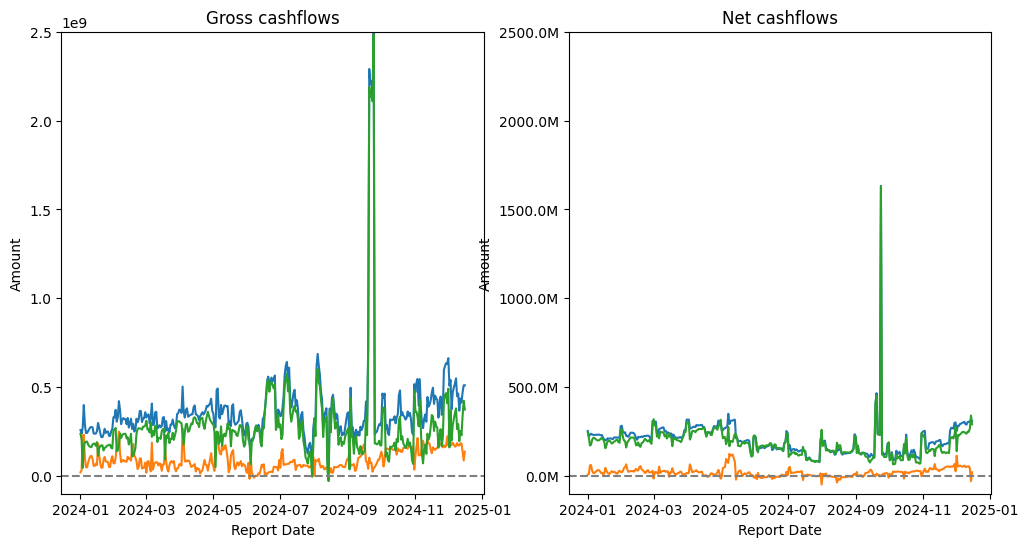

In [54]:
# 1. Define the subplot grid
rows, cols = 1, 2
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

y_min = -100000000
y_max = 2500000000

# Iterate through subplots and set y-axis limits
for ax in axes.flat:
    ax.set_ylim(y_min, y_max)


# Create the line plot
axes[0].plot(merged_df['report_dt'], merged_df['amount_eur_x'], label='inflows')
axes[0].plot(merged_df['report_dt'], merged_df['amount_eur_y'], label='outflows')
axes[0].plot(merged_df['report_dt'], merged_df['net_cash_outflow'], label='net cash outflow')
# Set common labels and title (optional)
axes[0].set_xlabel('Report Date')
axes[0].set_ylabel('Amount')
axes[0].set_title('Gross cashflows')
axes[0].axhline(y=0, color='grey', linestyle='--')


axes[1].plot(df7_inflows_weighted['report_dt'], df7_inflows_weighted['amount_eur_weighted'], label='inflows')
axes[1].plot(df7_outflows_weighted['report_dt'], df7_outflows_weighted['amount_eur_weighted'],  label='outflows')
axes[1].plot(merged_df7_weighted['report_dt'], merged_df7_weighted['net_cash_outflow_weighted'], label='net cash flow')
# Set common labels and title (optional)
axes[1].set_xlabel('Report Date')
axes[1].set_ylabel('Amount')
axes[1].set_title('Net cashflows')
axes[1].axhline(y=0, color='grey', linestyle='--')
# plt.ylim(0, 500000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()



In [55]:
merged_df7_weighted[merged_df7_weighted['report_dt']== datetime(2024,9,24).date()]

,report_dt,amount_eur_weighted_x,amount_eur_weighted_y,net_cash_outflow_weighted
267,2024-09-24,1.632642e+09,-2.856016e+06,1.629786e+09
